In [2]:
import sys
from datetime import datetime
import argparse
import os
import torch
import torch.nn as nn
from torch import einsum
import torch.distributed as dist
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel
from torch.utils.data import DataLoader
from einops.layers.torch import Rearrange, Reduce
from einops import rearrange

# Implementation of PTA-ViT3D Stage


## Theory:

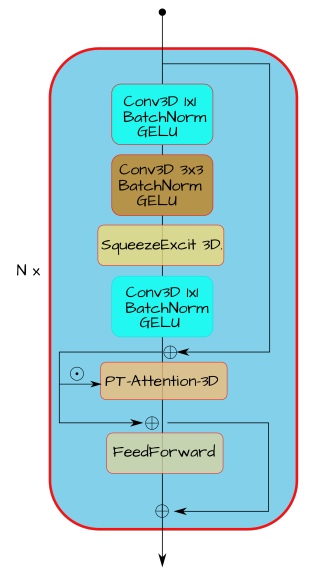

(figure-1)

Tanimoto Similarity is defined as: 
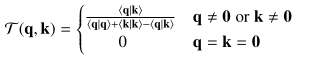

Here < q| k > denotes a form of inner product performed along selected dimension of tensor q and k. Initially both query (q), key (k) and value (v) tensor have the shape C x T x H x W. These are reshaped into smaller patches: It just reorganizes the tensor so that the first part (c, T, h, w) indexes which patch and the last part (C/c, H/h , W/w) holds the content of the patchh.

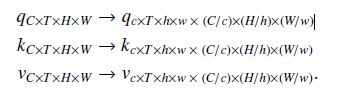

After patching the tensor q and k has 7 dimensions:

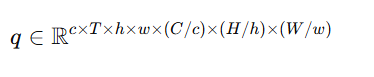

Once we have these sub-tensor (patches) we can compute the attention within patches efficiently. We can measure Tanimoto similarity between query and key paris at the patch level instead of per pixel level. It enable 3D attention that captures relationship across space + time + spectrum.

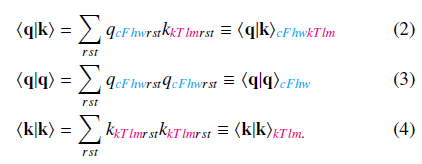

Here r,s,t are:
* r = index along channel inside patch (runs from 1 to C/c)
* s = index along height inside patch (runs from 1 to H/h)
* t = index along width inside patch (runs from 1 to W/w)

So for every combination of outer indices (C,F,h,w) from q and (K,T,l,m) form k we iterate through all the inner element (r,s,t) inside those two patches, multiplying them elementwise and sum. The summation removes the inner dimensions r,s,t exactly like a dot product.

Here each query patch is compared against a set of key patches to produce a similarity score for each query-key pair. That means 
* ⟨𝑞∣𝑘⟩𝑐𝑇ℎ𝑤𝑘𝑇𝑙𝑚: stores a similarity score for each query patch  (c,T,h,w) against each key patch (k,T,l,m). Pairwise similarity between query patch and a key patch.
* <q|q> : Self similarity computed by taking the inner product of the patch vector with itself.
* <k|k> : self similarity of each key patch, again one value per key patch.

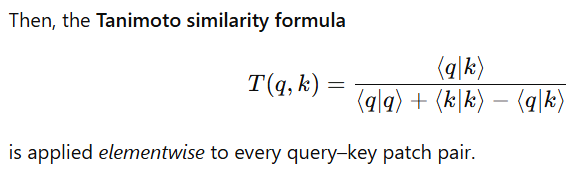

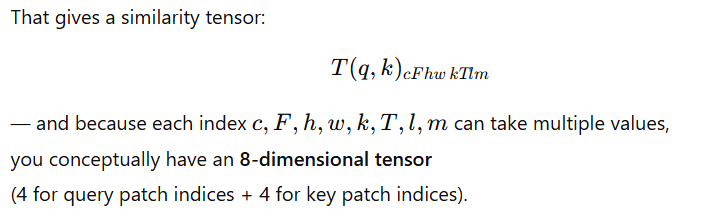

After computing all patch-to-patch similarities, the Tanimoto tensor is : 
T(q,k)cfhwkTlm
Each value = similarity between query patch (c, F, h, w) and key patch (k, T, l, m). If we count the possible values of those indices we have (number of query patches) x (number of key patches) which is a very big number.

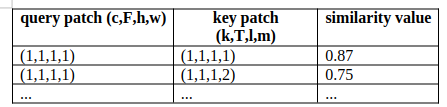

Let's say we have 2 channel group, 3 time step and 2x2 width and height per patch then. total 2x3x2x2 = 24 query patches.
Assume the key side also has 24 patches. then T(q,k) is 576 number. But we don't want 24 x24 = 576 similarity values per layers; we just want one scalar attention weight for each key patch that tells the network how important that key patch is overall relative to all queries. so we combine the 24 query contribution that correspond to each key patch.

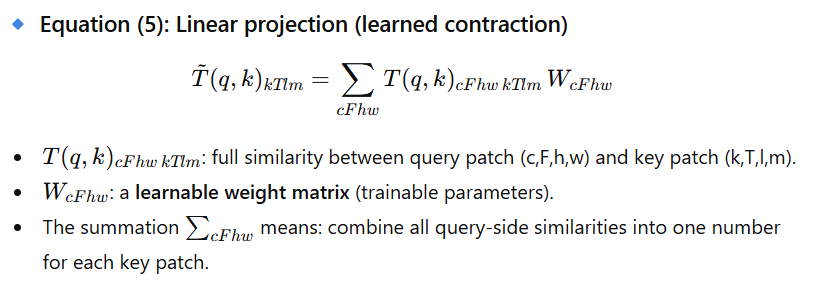

so the model learns how much to emphasize each query patch when computing attention toward every key patch. The output tensor now depends only on the key indices it has shape corresponding to the number of key patches and is thus 4 dimensions.

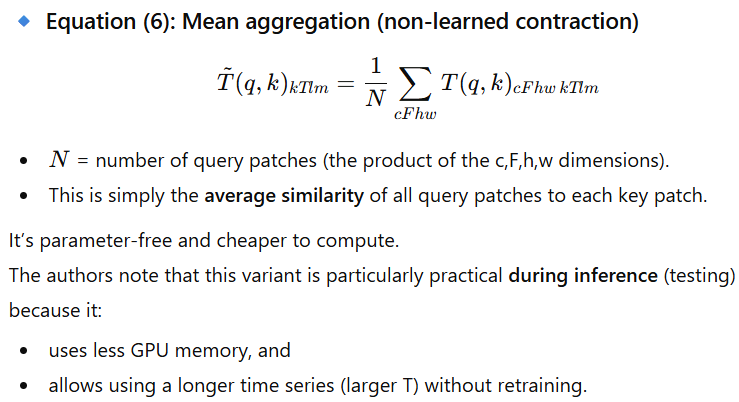

So we can use either hte learned contraction or non learned contraction to reduce the dimension.
When we have a time series, and we want to predict the future, our model should not use information from future time steps to infer the past. To enforce that, the paper introduced a mask matrix Mft defined by: 

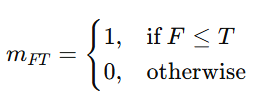

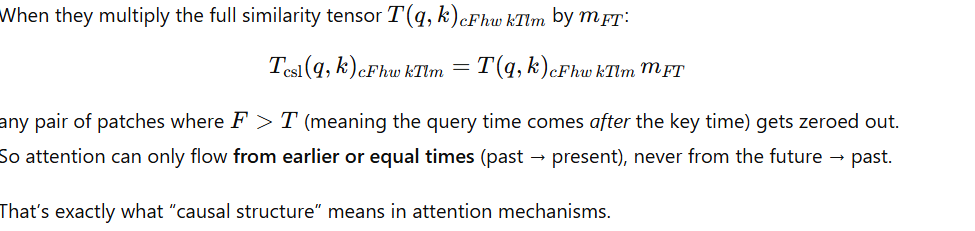

In any attention mechanism (Transformer-style) the idea is :

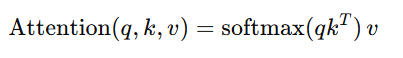

That is, we use similarity between queries and key to weight the values (v). Here the author do the same but with their own Tanimoto based similarity and 3D spatio-temporal patching.

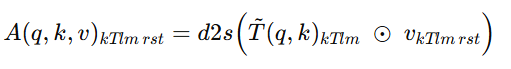

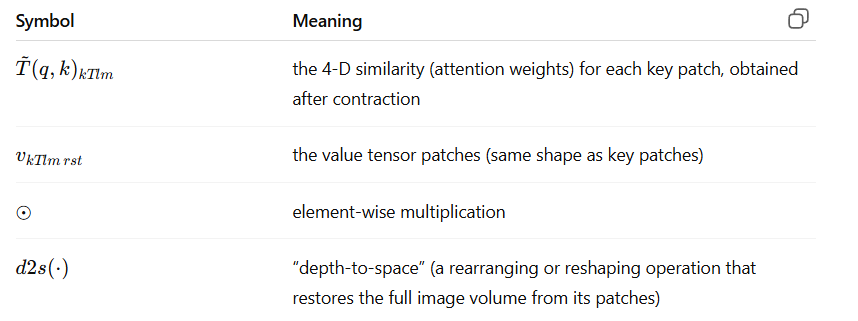

Because PTA3D computes similarity and weighting across: 
* Time (via T dimension)
* Space (via H and W patches)
* Channels (via partitioning along C)

The resulting attention map now encodes relation along all three axes:
* How each spectral bands relates to other (channel correlation)
* How pixel or local regions intersect spatially (spatial correlation)
* How feature evolve over multiple dates (temporal correlation)

The correlation are captured at the level of patches, not individual pixels. Where c, h, w are the number of partitions along channels, height and width. Each patch represents a small block (C/c x H/h x W/w) of the original tensor.  So the attention works at this coarser patch resolution. 
What d2s actually does:
Each attention-weighted patch knows its correct position given by its indices (k, T,l,m).
D2s takes all those little cubes and places them back in the right order to reconstruct the full spatio-temporal cube. 
The patch depth dimension (C/c, H/h, W/w) are rearranged back into the full C, H, W dimensions.


### Advantage over traditional separable channel spatial temporal method
Before PTA3D most 3D attention or video transformer approaches used a factorized strategy:
They compute attention independently along each axis:
    • One attention over channels (spectral bands)
    • Another over space (H x W)
    • Another over time (T)
and then combine them (often by adding or multiplying the outputs).
Formally, such separable attention assumes:

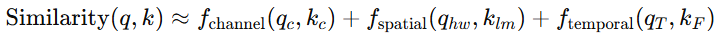

Where function f focuses on a single type of correlation.
This paper says that this factorization is a limitation because it breaks the joint relationship between those three dimensions.
In natural and remote sensing imagery:
Spectral features behave differently depending on the spatial context. Temporal dynamics vary by both spatial pattern and spectral signature. So the interaction between channels, space and time are entangled they cannot be cleanly separated. If we compute attention independently along each axis we lose those cross-dimensional dependencies.

Imagine a sentinel 2 pixel 
In the NIR band, vegetation is bright
In the Red band, it’s darker
Over time, it changes differently in crops.
If we only compute temporal similarity within each band (separately), we’ll miss that the joint evolution across bands tells us what’s actually happening.

## General Part Code:

In [3]:
class SqueezeExcitation3D(nn.Module):
    def __init__(self, dim, shrinkage_rate = 0.25):
        super().__init__()
        hidden_dim = int(dim * shrinkage_rate)
        self.gate = nn.Sequential(
            Reduce('b c s h w -> b s c', 'mean'),
            nn.Linear(dim, hidden_dim, bias = False),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim, bias = False),
            nn.Sigmoid(),
            Rearrange('b s c -> b c s 1 1')
        )
    def forward(self, x):
        return x * self.gate(x)

model.train() tells model that you are in training model. This helps layers such as Dropout and BatchNorm, which are designed to behave differently during training and evaluation. For example, in training mode, BatchNorm updates a moving average on each new batch; whereas for evaluation mode these update are frozen.

Dropsample is implementing stochastic depth: during training, it randomly removes the residual branch for some samples, so the block behaves like an identity mapping for those samples. This is used as regularization: it trains an implicit ensemble of “shallower” subnetworks during training, which tends to improve generalization and can make very deep residual networks easier to train. if we only did x * keep_mask then the output would be smaller on average during training, because we are zeroing it with probability prob. That creates a scale mismatch between training (where the branch is often partially missing) and inference (where the branch is never dropped). So we use the standard "invereted dropout" trick which rescales the kept cases so that the expected value stays about the same during training. 

In [4]:
class Dropsample(nn.Module):
    def __init__(self, prob = 0):
        super().__init__()
        self.prob = prob
    def forward(self, x):
        device = x.device
        if self.prob == 0. or (not self.training):
            return x
        keep_mask = torch.FloatTensor((x.shape[0], 1, 1, 1, 1), device = device).uniform_() > self.prob
        return x * keep_mask / (1 - self.prob)
        
class MBConvResidual3D(nn.Module):
    def __init__(self, fn, dropout = 0.):
        super(). __init__()
        self.fn = fn
        self.dropsample = Dropsample(dropout)

    def forward(self, x):
        out = self.fn(x)
        out = self.dropsample(out)
        return out + x

In [5]:
def MBConv3D(
    dim_in,
    dim_out,
    *,
    downsample,
    expansion_rate = 4,
    shrinkage_rate = 0.25,
    dropout = 0.,
):
    """
    MBConv3D = Mobile Inverted Bottleneck Convolution (3D variant):

    parameters:
    - dim_in:
        Input channel count (C_in) of the incoming feature volume.
    - dim_out:
        Output channel count (C_out) produced by the block.
    - downsample:
        If True, performs spatial downsampling using stride (1,2,2). This reduces H and W by 2,
        while keeping time/sequence dimension unchanged (stride 1 in T).
    - expansion_rate:
        Controls how wide the hidden (“expanded”) channel dimension is:
            hidden_dim = int(expansion_rate * dim_out)
        Larger values increase capacity and compute.
    - shrinkage_rate:
        Controls the SE bottleneck size:
            se_hidden_dim = int(hidden_dim * shrinkage_rate)
        Smaller values make SE cheaper (and less expressive)
    - dropout:
        Used only when a residual path is present; applied as drop-path / stochastic depth on the
        residual branch output (drops whole residual contributions per-sample during training). :contentReference[oaicite:3]{index=3}

    Returns
    - nn.Module that maps (B, dim_in, T, H, W) -> (B, dim_out, T, H', W'),
      where H',W' depend on downsample.
    """
    hidden_dim = int(expansion_rate * dim_out)
    # Only downsample spatially (H,W). Time dimension is not downsampled.
    stride = (1,2,2) if downsample else (1,1,1)
    conv3d_spatial = nn.Conv3d(hidden_dim, hidden_dim, (3,3,3), stride = stride, padding = (1,1,1), groups = hidden_dim)
    net = nn.Sequential(
        # Expand (pointwise 1x1x1). It's kernel size is 1 in time and space, so it mixes only across channels, not across pixels or time frames
        nn.Conv3d(dim_in, hidden_dim, 1),
        nn.BatchNorm3d(hidden_dim),
        nn.GELU(),
        # 3×3×3 DEPTHWISE conv to mix local spatio-temporal context
        conv3d_spatial,
        nn.BatchNorm3d(hidden_dim),
        nn.GELU(),
        ## Each channel now encodes a different learned pattern for example (vegetation, moisture, temporal change intensity). But the model doens't yet
        ## know which channel are more relevant for the current sample. All channel are treated equally. The SE3D block lets the model dynamically reweight
        ## channels.
        SqueezeExcitation3D(hidden_dim, shrinkage_rate = shrinkage_rate),
        nn.Conv3d(hidden_dim, dim_out, 1),
        nn.BatchNorm3d(dim_out)
    )
    if dim_in == dim_out and not downsample:
        net = MBConvResidual3D(net, dropout = dropout)
    return net

In [6]:
class LayerNormChannelsLast3D(nn.Module):
    """
    Creates a LayerNorm that normalize the last dimension of its input LayerNorm normalizes by subtracting the mean and dividing by the standard deviation, then applies learned scale/biases.
    """
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)

    def forward(self, input):
        # Here the tensor is in channel first format, but the LayerNorm expect the dimension to normalize to be the last one.
        x = rearrange(input,'b c s h w-> b s h w c')
        x = self.norm(x)
        x = rearrange(x,'b s h w c -> b c s h w')
        return x

class PreNormResidualAtt3D(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = LayerNormChannelsLast3D(dim)
        self.fn = fn

    def forward(self, x):
        ## As we can see in the figure (1) there is the skip connection with the multiplication and additon
        '''
        The PT-Attention module is producing an important map. Multiplying by x makes that map behave like "how much of the existing feature should pass through here." Also, here +1 makes it an identity
        so the block can easily behave like an identity mapping early in training, which improves stability one of the main reasons residual designs work well. 
        Why +1 and multiplication ? 
        1. Identity centered behavior (easy "do nothing")
            If the attention output is near zero, then: 
                y =(0+1)*x = x
            That means the block can start training as a near identity mapping, which makes optimization easier and keeps gradients flowing well in deep network. 
        2. Gating (feature wise reweighting) rather than additive injection
            Multiplication makes attention behave like a gate on existing features: it decides what to pass though / suppress / amplify at eadch location. This iis common patter in "gated residual" designs, where the learned component moduleaes the sign .
        3. It prevents "feature wipeout " if the gate is near 0
            if we did y = g(x) * x without no +1 then whenever g(x) is near 0, the block output near 0, which can unnecessarily erase information early in training. Adding 1 ensure the baseline is pass through, not "shut off".
        '''
        return (self.fn(self.norm(x)) + 1)*x

## Patch Attention Code (Equation Equivalent from the paper )

In [7]:
import torch

def get_norm3d(name,channels,num_groups=None):
    if name == 'BatchNorm':
        return torch.nn.BatchNorm3d(num_features=channels)
    elif name == 'GroupNorm':
        return torch.nn.GroupNorm(num_channels=channels,num_groups=num_groups)
    else:
        raise ValueError("I do not understand normalization name::{}, options:: BatchNorm, GroupNorm, aborting ...".format(name))

def get_norm2d(name,channels,num_groups=None):
    if name == 'BatchNorm':
        return torch.nn.BatchNorm2d(num_features=channels)
    elif name == 'GroupNorm':
        return torch.nn.GroupNorm(num_channels=channels,num_groups=num_groups)
    else:
        raise ValueError("I do not understand normalization name::{}, options:: BatchNorm, GroupNorm, aborting ...".format(name))

def get_norm1d(name,channels,num_groups=None):
    if name == 'BatchNorm':
        return torch.nn.BatchNorm1d(num_features=channels)
    elif name == 'GroupNorm':
        return torch.nn.GroupNorm(num_channels=channels,num_groups=num_groups)
    else:
        raise ValueError("I do not understand normalization name::{}, options:: BatchNorm, GroupNorm, aborting ...".format(name))

In [8]:
import torch

class Conv2DNormed(torch.nn.Module):
    """
        Convenience wrapper layer for 2D convolution followed by a normalization layer 
    """

    def __init__(self, in_channels, out_channels, kernel_size, strides=(1, 1),
                 padding=(0, 0), dilation=(1, 1), norm_type = 'BatchNorm', num_groups=None, 
                 groups=1):
        super(Conv2DNormed,self).__init__()

        self.conv2d = torch.nn.Conv2d(in_channels=in_channels, 
                                      out_channels=out_channels,
                                      kernel_size= kernel_size,
                                      stride= strides,
                                      padding=padding,
                                      dilation= dilation,
                                      bias=False,
                                      groups=groups)
        self.norm_layer = get_norm2d(name=norm_type,channels=out_channels,num_groups=num_groups)

    @torch.jit.export
    def forward(self,input:torch.Tensor):

        x = self.conv2d(input)
        x = self.norm_layer(x)

        return x

In [9]:
import torch

class Conv3DNormed(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, strides=(1, 1,1),
                 padding=(0, 0, 0), dilation=(1, 1, 1), norm_type = 'BatchNorm', num_groups=None, 
                 groups=1):
        super(Conv3DNormed,self).__init__()

        self.conv3d = torch.nn.Conv3d(in_channels=in_channels, 
                                      out_channels=out_channels,
                                      kernel_size= kernel_size,
                                      stride= strides,
                                      padding=padding,
                                      dilation= dilation,
                                      bias=False,
                                      groups=groups)
        self.norm_layer = get_norm3d(name=norm_type,channels=out_channels,num_groups=num_groups)

    @torch.jit.export
    def forward(self,input:torch.Tensor):

        x = self.conv3d(input)
        x = self.norm_layer(x)

        return x

In [10]:
class UpSample2D(torch.nn.Module):
    def __init__(self, in_channels, out_channels, scale_factor=2, mode='nearest', norm_type = 'BatchNorm', norm_groups=None):
        super(UpSample2D,self).__init__()
        self.upsample = torch.nn.Upsample(scale_factor=scale_factor, mode=mode)
        self.convup_normed= Conv2DNormed(in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=3,
                padding=1,
                norm_type=norm_type,
                num_groups=norm_groups)
        
    def forward(self,input):
        out = self.upsample(input)
        out = self.convup_normed(out)
        return out


class UpSample2D3D(torch.nn.Module):
    def __init__(self, in_channels, out_channels, scale_factor=2, mode='nearest', norm_type = 'BatchNorm', norm_groups=None,causal=False):
        super().__init__()
        self.upsample = torch.nn.Upsample(scale_factor=(1,scale_factor,scale_factor), mode=mode)
        self.convup_normed= Conv3DNormed(in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=(3,3,3),
                    padding=(1,1,1),
                    norm_type=norm_type,
                    num_groups=norm_groups)
    def forward(self,input):
        out = self.upsample(input)
        out = self.convup_normed(out)
        return out

In [11]:
import torch

class D2SigmoidFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx,x):
        
        u = torch.special.expit(-x)
        ctx.save_for_backward(u)
        return u*(1. + u*(-3. + 2.*u))
        
    @staticmethod
    def backward(ctx,grad_output):
        u = ctx.saved_tensors[0]
        return u*(-1. + u*(7. + u*(-12. + 6.*u)))*grad_output

class D2Sigmoid(torch.nn.Module):
    def __init__(self,scale=False):
        super(D2Sigmoid,self).__init__()
        
    def forward(self,input):
        return D2SigmoidFunction.apply(input)
        

In [12]:
class Patchify3DCHW(torch.nn.Module):
    def __init__(self, cscale, hscale, wscale):
        super().__init__()
        self.c = cscale
        self.h = hscale
        self.w = wscale
        self.unfold_shape = None

    def _2patch(self, input):
        shape = input.shape
        c = torch.div(shape[-3], self.c, rounding_mode="floor")
        h = torch.div(shape[-2], self.h, rounding_mode="floor")
        w = torch.div(shape[-1], self.w, rounding_mode="floor")

        sc = c
        sh = h
        sw = w

        patch = input.unfold(2, c, sc).unfold(3, h, sh).unfold(4, w, sw)
        self.unfold_shape = patch.shape
        return patch

    def _2tensor(self, patch):
        if self.unfold_shape is None:
            raise RuntimeError("unfold_shape is None. Call _2patch() before _2tensor().")

        output_c = self.unfold_shape[2] * self.unfold_shape[5]
        output_h = self.unfold_shape[3] * self.unfold_shape[6]
        output_w = self.unfold_shape[4] * self.unfold_shape[7]

        tensorpatch = patch.permute(0, 1, 2, 5, 3, 6, 4, 7).contiguous()
        tensorpatch = tensorpatch.view(
            self.unfold_shape[0],
            self.unfold_shape[1],
            output_c,
            output_h,
            output_w,
        )
        return tensorpatch

    def forward(self, x):
        # Optional convenience: returns patches
        return self._2patch(x)


class BASE_RelPatchAttention3D_TCHW(torch.nn.Module):
    def __init__(self, nfilters, scales, correlation_method="sum", TimeDim=None, depth=0.0):
        super().__init__()

        self.alpha = 2.0 ** depth
        self.beta = 2.0 * self.alpha - 1

        if depth == 0.0:
            self.qk_sim = self._qk_identity_sim_v1
        else:
            self.qk_sim = self._qk_identity_sim_v2

        self.scales = scales
        self.patchify = Patchify3DCHW(cscale=scales[0], hscale=scales[1], wscale=scales[2])

        if correlation_method == "sum":
            self.qk_compact = self._qk_compact_v1
        elif correlation_method == "mean":
            self.qk_compact = self._qk_compact_v2
        elif correlation_method == "linear":
            if TimeDim is None:
                raise ValueError("TimeDim must be provided when correlation_method='linear'.")
            self.shrink_2_1 = torch.nn.Linear(
                in_features=TimeDim * scales[0] * scales[1] * scales[2],
                out_features=1,
            )
            self.qk_compact = self._qk_compact_v3
        else:
            raise ValueError("Cannot understand correlation method, aborting ...")

    def _qk_identity_sim_v1(self, q, k, smooth=1.0e-5):
        scale = np.reciprocal(np.sqrt(np.prod(q.shape[-3:])))
        q = q * scale
        k = k * scale

        qk = einsum("iWjklmno,iPstrmno->iWjklPstr", q, k)
        qq = einsum("iWjklmno,iWjklmno->iWjkl", q, q)
        kk = einsum("iPstrmno,iPstrmno->iPstr", k, k)

        denum = (qq[:, :, :, :, :, None, None, None, None] + kk[:, None, None, None, None]) - qk + smooth
        logqk = torch.log(qk + smooth)
        logdenum = torch.log(denum)
        result = torch.exp(logqk - logdenum)
        return result

    def _qk_identity_sim_v2(self, q, k, smooth=1.0e-5):
        scale = np.reciprocal(np.sqrt(np.prod(q.shape[-3:])))
        q = q * scale
        k = k * scale

        qk = einsum("iWjklmno,iPstrmno->iWjklPstr", q, k)
        qq = einsum("iWjklmno,iWjklmno->iWjkl", q, q)
        kk = einsum("iPstrmno,iPstrmno->iPstr", k, k)

        denum = self.alpha * (qq[:, :, :, :, :, None, None, None, None] + kk[:, None, None, None, None]) - self.beta * qk + smooth
        logqk = torch.log(qk + smooth)
        logdenum = torch.log(denum)
        result = torch.exp(logqk - logdenum)
        return result

    def _qk_compact_v1(self, qk):
        return torch.sum(qk, dim=1)

    def _qk_compact_v2(self, qk):
        return torch.mean(qk, dim=1)

    def _qk_compact_v3(self, qk):
        tqk = qk.permute(0, 2, 3, 4, 5, 1)
        tqk2 = self.shrink_2_1(tqk).squeeze(dim=-1)
        return tqk2

    def qk_select_v(self, qk, vpatch, smooth=1.0e-5):
        tqk = qk.reshape(qk.shape[0], -1, *qk.shape[5:])
        tqk = self.qk_compact(tqk)
        qkvv = einsum("bTrst, bTrstmno -> bTrstmno", tqk, vpatch)
        qkvv = self.patchify._2tensor(qkvv)
        return qkvv

    def get_att(self, q, k, v):
        qp = self.patchify._2patch(q)
        kp = self.patchify._2patch(k)
        vp = self.patchify._2patch(v)

        qpkp = self.qk_sim(qp, kp)
        vout = self.qk_select_v(qpkp, vp)
        return vout


In [13]:
class RelPatchAttention3DTCHW(torch.nn.Module):
    def __init__(self,in_channels,out_channels,scales,kernel_size=(3,3,3),padding=(1,1,1),nheads=1,norm='BatchNorm',norm_groups=None, correlation_method='sum',  TimeDim=None,depth=0.0):
        super().__init__()
        self.act = D2Sigmoid(scale = False)
        self.patch_attention = BASE_RelPatchAttention3D_TCHW(out_channels, scales, correlation_method=correlation_method,TimeDim=TimeDim,depth=depth)
        self.query   = Conv3DNormed(in_channels=in_channels,out_channels=out_channels,kernel_size= kernel_size, padding = padding, norm_type= norm, num_groups=norm_groups, groups=nheads)
        self.kv      = Conv3DNormed(in_channels=in_channels,out_channels=out_channels*2,kernel_size= kernel_size, padding = padding, norm_type= norm, num_groups=norm_groups, groups=nheads*2)

    def forward(self, input1:torch.Tensor, input2: torch.Tensor):
        q = self.query(input1)
        k,v = self.kv(input2).split(q.shape[1],1)
        q = self.act(q)+0.1
        k = self.act(k)+0.1
        q = q.permute(0,2,1,3,4)
        k = k.permute(0,2,1,3,4)
        v = v.permute(0,2,1,3,4)
        v = self.patch_attention.get_att(q,k,v)
        v = v.permute(0,2,1,3,4)
        v = self.act(v)
        return v

In [14]:
class PTAttention3DTCHW(nn.Module):
    def __init__(
        self,
        dim,
        nheads = 32,
        dropout = 0.,
        scales = (4,4),
        verbose=False,
        correlation_method='mean',
        TimeDim=None,
        depth=10.0
    ):
        super().__init__()
        if verbose:
            print("nfilters::{}, scales::{}, nheads::{}".format(dim, scales,nheads))
        self.att      =  RelPatchAttention3DTCHW(
                                in_channels  	   = dim,
                                out_channels 	   = dim,
                                nheads       	   = nheads,
                                scales       	   = scales,
                                norm         	   = 'GroupNorm',
                                norm_groups  	   = dim//4,
                                correlation_method = correlation_method,
                                TimeDim            = TimeDim, 
                                depth 		   = depth)

    def forward(self,input):       
        return   self.att(input,input)

In [15]:
class PreNormResidual3D(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = LayerNormChannelsLast3D(dim)
        self.fn = fn

    def forward(self, x):
        return self.fn(self.norm(x)) + x

In [16]:

class FeedForward3D(nn.Module):
    def __init__(self, dim, mult = 4, dropout = 0.):
        super().__init__()
        inner_dim = int(dim * mult)
        self.net = nn.Sequential(
            nn.Linear(dim, inner_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        x = rearrange(x,'b c s h w -> b s h w c')
        x = self.net(x)
        return rearrange(x,'b s h w c -> b c s h w')

In [17]:
class PTAViTStage3DTCHW(nn.Module):
    """
    PTAViT3D stage composed of repeated 3D MBConv + PTA3D attention + 3D feed-forward blocks.

    This module implements one hierarchical stage in the PTAViT3D encoder/decoder. A stage is
    formed by stacking `layer_depth` identical blocks. Each block follows the pattern:

        1) MBConv3D: local 3D convolutional mixing (optionally downsampling, typically only
           on the first block of the stage),
        2) PreNormResidualAtt3D(PTAttention3DTCHW): 3D Patch-Tanimoto Attention wrapped with
           pre-normalization and a residual connection,
        3) PreNormResidual3D(FeedForward3D): transformer-style 3D feed-forward network wrapped
           with pre-normalization and a residual connection.

    Parameters
    ----------
    layer_dim_in : int
        Number of input channels to the stage (used by the first block when stage changes width).
    layer_dim : int
        Number of output channels produced by the stage (and used internally by all blocks).
    layer_depth : int
        Number of repeated blocks inside the stage (corresponds to "N×" in the stage diagram).
    nheads : int
        Number of attention heads used by the PTAttention3DTCHW module.
    scales : Sequence[int] or Sequence[Sequence[int]]
        Stage-specific scale hyperparameters forwarded to the attention/correlation machinery
        (e.g., channel/spatial association granularity).
    downsample : bool, default=False
        If True, enables downsampling in the stage (intended to be applied only in the first block).
    mbconv_expansion_rate : int, default=4
        Expansion ratio used inside MBConv3D (pointwise expansion width factor).
    mbconv_shrinkage_rate : float, default=0.25
        Shrinkage/projection ratio used inside MBConv3D (e.g., for squeeze/excitation or projection).
    dropout : float, default=0.1
        Dropout probability used in attention and feed-forward modules.
    correlation_method : str, default="mean"
        Strategy used by the attention module to contract/aggregate correlation/association information.
    TimeDim : int or None, default=None
        Time dimension configuration passed into the attention module (e.g., number of snapshots).
    depth : float, default=10.0
        Scalar hyperparameter forwarded to the attention module (e.g., controlling association depth).

    Inputs
    ------
    input : torch.Tensor
        5D tensor expected in Conv3D layout, typically (B, C, T, H, W).
    Returns
    -------
    torch.Tensor
        Output tensor after applying the stacked stage blocks. Channel count is `layer_dim`;
        spatial/temporal resolution depends on whether downsampling is enabled in MBConv3D.
    """
    def __init__(
        self,
        layer_dim_in,
        layer_dim,
        layer_depth,
        nheads,
        scales,
        downsample=False,
        mbconv_expansion_rate = 4,
        mbconv_shrinkage_rate = 0.25,
        dropout = 0.1,
        correlation_method="mean",
        TimeDim = None,
        depth = 10.0
    ):
        super(). __init__()
        stage = []
        for stage_ind in range(layer_depth):
            is_first = stage_ind == 0
            block = nn.Sequential(
                MBConv3D(
                    layer_dim_in if is_first else layer_dim,
                    layer_dim,
                    downsample = downsample if is_first else False,
                    expansion_rate = mbconv_expansion_rate,
                    shrinkage_rate = mbconv_shrinkage_rate,
                ),
                PreNormResidualAtt3D(
                    layer_dim,
                    PTAttention3DTCHW(
                        dim = layer_dim,
                        nheads = nheads,
                        dropout = dropout,
                        scales = scales,
                        correlation_method = correlation_method,
                        TimeDim = TimeDim,
                        depth = depth
                    )
                ),
                PreNormResidual3D(
                    layer_dim,
                    FeedForward3D(
                        dim = layer_dim,
                        dropout = dropout
                    )
                )
            )
            stage.append(block)

        self.stage = torch.nn.Sequential(*stage)

    def forward(self, input):
        return self.stage(input)
        

In [18]:
class combine_layers(torch.nn.Module):
    def __init__(self,nfilters,  norm_type = 'BatchNorm', norm_groups=None):
        super(combine_layers,self).__init__()


        # This performs convolution, no BatchNormalization. No need for bias.
        self.up = UpSample2D(in_channels=nfilters*2, out_channels=nfilters, norm_type = norm_type, norm_groups=norm_groups)

        self.conv_normed = Conv2DNormed(in_channels = 2*nfilters,out_channels=nfilters,
                                            kernel_size=(1,1),
                                            padding=(0,0),
                                            norm_type=norm_type,
                                            num_groups=norm_groups)




    def forward(self,_layer_lo, _layer_hi):
        up = self.up(_layer_lo)

        up = torch.relu(up)
        x = torch.cat([up,_layer_hi], dim=1)
        x = self.conv_normed(x)

        return x

class combine_layers3D(torch.nn.Module):
    def __init__(self,nfilters,  norm_type = 'BatchNorm', norm_groups=None,causal=False):
        super().__init__()


        # This performs convolution, no BatchNormalization. No need for bias.
        self.up = UpSample2D3D(in_channels=nfilters*2, out_channels=nfilters, norm_type = norm_type, norm_groups=norm_groups, causal=causal)

        self.conv_normed = Conv3DNormed(in_channels = 2*nfilters,out_channels=nfilters,
                                            kernel_size=(1,1,1),
                                            padding=(0,0,0),
                                            norm_type=norm_type,
                                            num_groups=norm_groups)




    def forward(self,_layer_lo, _layer_hi):
        up = self.up(_layer_lo)

        up = torch.relu(up)
        x = torch.cat([up,_layer_hi], dim=1)
        x = self.conv_normed(x)

        return x

# UNET Architecture Single sensor Input

In [19]:
class FusionCAT(torch.nn.Module):
    def __init__(self,nfilters_in,nfilters_out, nheads, kernel_size=3, padding=1, norm = 'BatchNorm', norm_groups=None):
        super().__init__()
        
        self.fuse = Conv3DNormed(in_channels=nfilters_in*2, out_channels=nfilters_out,kernel_size= kernel_size, padding = padding, norm_type= norm, num_groups=norm_groups, groups=nheads)

    def forward(self, out12, out21):

        fuse = self.fuse(torch.cat([out12, out21],dim=1))
        fuse = torch.relu(fuse)

        return fuse


class FuseHiLo(torch.nn.Module):
    def __init__(self, nfilters, nfilters_embed=96, scales=(4,8,8),   norm_type = 'BatchNorm', norm_groups=None,depth=10.0):
        super().__init__()



        self.embedding1 = Conv3DNormed(in_channels = nfilters, out_channels = nfilters_embed, kernel_size = 1, padding=0, norm_type=norm_type, num_groups=norm_groups)
        self.embedding2 = Conv3DNormed(in_channels = nfilters, out_channels = nfilters_embed, kernel_size = 1, padding=0, norm_type=norm_type, num_groups=norm_groups)


        self.upscale = UpSample2D3D(in_channels=nfilters_embed,out_channels=nfilters_embed,scale_factor=4,norm_type=norm_type,norm_groups=norm_groups)


        self.conv3d = Conv3DNormed(in_channels=nfilters_embed*2, out_channels = nfilters_embed,kernel_size =1, norm_type=norm_type, num_groups=norm_groups)
        self.att = RelPatchAttention3DTCHW(in_channels=nfilters_embed, out_channels = nfilters_embed,nheads=nfilters_embed//4,norm=norm_type,norm_groups=norm_groups,
                scales=scales,
                depth=depth
              )


    def forward(self, UpConv4, conv1):
        UpConv4 = self.embedding1(UpConv4)
        UpConv4 = self.upscale(UpConv4)
        conv1   = self.embedding2(conv1)
        convl = torch.cat([conv1,UpConv4],dim=1)
        conv = self.conv3d(convl)
        conv = torch.relu(conv)
        conv = conv * (1.+self.att(conv,conv))

        return conv


In [20]:
# class ptavit3d_dn_features(torch.nn.Module):
#     def __init__(self,  in_channels, spatial_size_init, nfilters_init=96, nfilters_embed=32, nheads_start=96//4, depths=[2,2,5,2], verbose=True, norm_type='GroupNorm', norm_groups=4, correlation_method='mean', TimeDim=None, attention_depth=0.0,stem_norm=True):
#         super().__init__()

#         def closest_power_of_2(num_array):
#             """
#             The purpose of this is to take a set of compute scale values and snap them to clean, safe, implementation-friendly values.
#             * Preserve divisibility across U-Net resolution levels
#                 Downsampling/upsampling in U-Nets typically happens by factor of 2. If our scale parameters are also power of 2, they stay compatible as spatial sizes shrink
#                 grow.
#             * Make reshaping/patch partitioning reliable
#                 Patch based attention frequently reshapes tensors into block. Power of two reduce the chance that H or W cannot be evenly partitioned.
#             * Keep compute/memory behavior stable and predictable
#                 Many efficient kernels and hierarchical designs behave best with powers of two size.
#             """
#             log2_array = np.log2(num_array)
#             rounded_log2_array = np.round(log2_array)
#             closest_power_of_2_array = np.power(2, rounded_log2_array)
#             return np.maximum(closest_power_of_2_array, 1).astype(int)
    
    
#         def resize_scales(channel_size, spatial_size, scales_all):
#             """
#             It asssumes the original scale_all list was tuned for a reference setup of 96 and channels of [256,256].
#             If our actual setup is smaller it scales the scale parameters down. 
#             """
#             temp = np.array(scales_all)*np.array([channel_size/96,spatial_size[0]/256,spatial_size[1]/256])
#             return closest_power_of_2(temp).tolist()

#         scales_all = [[16,16,16],[32,8,8],[64,4,4],[128,2,2],[128,2,2],[128,1,1],[256,1,1],[256,1,1]] # DEFAULT, nice results 
#         scales_all = resize_scales(nfilters_init, spatial_size_init,scales_all)
#         self.scales_all = scales_all
#         # depth of the U-Net architecutre. Here the depth indicate the number of PTAViT3D model in the encoder so it's [2,2,5,2] so we have 4 encoder block.
#         self.depth = depth = len(depths)
#         num_stages = len(depths)
#         # now it generat the feature channel width per stage
#         dims = tuple(map(lambda i: (2 ** i) * nfilters_init, range(num_stages)))
#         # add the n_filter_init in front of the existing dims.
#         dims = (nfilters_init, *dims)
#         # it generate the input size and the output size from the each encoder block.
#         dim_pairs = tuple(zip(dims[:-1], dims[1:]))
    
#         self.conv1 = Conv3DNormed(in_channels=in_channels, out_channels = nfilters_init, kernel_size=1,padding=0,strides=1, norm_type=norm_type, num_groups=norm_groups)
#         if stem_norm:
#             self.conv_stem = nn.Sequential(
#             nn.Conv3d( nfilters_init, nfilters_init, (3,3,3), stride = (1,2,2), padding = (1,1,1)),
#             nn.GroupNorm(num_groups=norm_groups, num_channels=nfilters_init),
#             nn.Conv3d(nfilters_init, nfilters_init, 3, padding = 1),
#             nn.GroupNorm(num_groups=norm_groups, num_channels=nfilters_init)
#             )
#         else:
#             self.conv_stem = nn.Sequential(
#             nn.Conv3d( nfilters_init, nfilters_init, (3,3,3), stride = (1,2,2), padding = (1,1,1)),
#             nn.Conv3d(nfilters_init, nfilters_init, 3, padding = 1)
#             )
#         ## The reason it uses //4 is that, in this architecture, the spatial resolution is reduced twice before the model considers itself "at the start of stage 0". Basically there is another stride in the ptavit3d. it also consider this.
#         spatial_size_init = tuple(ts // 4 for ts in spatial_size_init)
#         # the actual downsampling encoder stages
#         self.stages_dn = []
#         # extra fusion blocks intended for combining two streams/ two feature tensors.
#         self.fuse = []
#         self.atts_fuse = []
#         if verbose:
#             print("@@@@@@@@@@@@@@@@@   Encoder Block Going Down   @@@@@@@@@@@@@@@@@@@@@")
#         for idx, ((layer_dim_in, layer_dim), layer_depth) in enumerate(zip(dim_pairs, depths)):
#             nheads = nheads_start * 2**idx
#             scales = scales_all[idx]
#             spatial_size = tuple( ts // 2**idx for ts in spatial_size_init )
#             if verbose:
#                 print ("depth:= {0}, layer_dim_in: {1}, layer_dim: {2}, stage_depth::{3}, spatial_size::{4}, scales::{5}".format(idx,layer_dim_in,layer_dim,layer_depth,spatial_size, scales)) 
#             self.stages_dn.append(PTAViTStage3DTCHW(
#                 layer_dim_in = layer_dim_in, # input feature channels entering this stage
#                 layer_dim = layer_dim, # output feature channels produced by this stage
#                 layer_depth = layer_depth, # How many ptavit3d blocks are repeated inside this stage
#                 nheads = nheads, # the number of attention head also the number of channel group
#                 scales = scales, # patch partitioning resolution used by Patch Tanimoto Attention.
#                 downsample= True, # downsampled spatially (H/W reduced)
#                 mbconv_expansion_rate = 4, # expansion inside the MBConv of ptavit3d so internally the block may go from c -> 4c
#                 mbconv_shrinkage_rate = 0.25, # Used in Squeeze-Excitation after MBConv block in ptavit3d
#                 dropout = 0.1, 
#                 correlation_method = correlation_method, # how the patch-tanimoto tensor is contracted/aggregated
#                 TimeDim = TimeDim, # Length of the time dimension
#                 depth = attention_depth # 
#             ))
#             self.fuse.append(FusionCAT(
#                 nfilters_in = layer_dim,
#                 nfilters_out = layer_dim,
#                 nheads = nheads,
#                 norm = norm_type,
#                 norm_groups = norm_groups
#             ))
#             self.atts_fuse.append(RelPatchAttention3DTCHW(
#                 in_channels = layer_dim,
#                 out_channels = layer_dim,
#                 kernel_size = 3,
#                 padding = 1,
#                 nheads = nheads,
#                 norm = norm_type,
#                 norm_groups = norm_groups,
#                 scales = scales,
#                 correlation_method = correlation_method,
#                 TimeDim = TimeDim,
#                 depth = attention_depth
#             ))
#         self.stages_dn = torch.nn.ModuleList(self.stages_dn)
#         self.fuse     = torch.nn.ModuleList(self.fuse)
#         self.atts_fuse     = torch.nn.ModuleList(self.atts_fuse)
#         self.stages_up = []
#         self.UpCombs = []
#         dim_pairs = dim_pairs[::-1]
#         depths = depths[::-1]
#         dim_pairs = dim_pairs[:-1]
#         depths = depths[1:]
#         if verbose: 
#             print("@@@@@@@@@@@@@@@@@   Decoder Block coming up   @@@@@@@@@@@@@@@@@@@@@")
#             for idx, ((layer_dim_in, layer_dim), layer_depth) in enumerate(zip(dim_pairs, depths)):
#                 idx = len(depths) - 1 - idx
#                 nheads = int(nheads_start * 2 **(idx))
#                 spatial_size = tuple(ts // 2 ** idx for ts in spatial_size_init)
#                 scales = scales_all[idx]
#                 if verbose:
#                     print ("depth:= {0}, layer_dim_in: {1}, layer_dim: {2}, stage_depth::{3}, spatial_size::{4}, scales::{5}".format(2*depth-idx-2, 
#                         layer_dim_in, layer_dim_in, layer_depth,spatial_size, scales))
    
#                 self.stages_up.append(PTAViTStage3DTCHW(
#                     layer_dim_in = layer_dim_in,
#                     layer_dim = layer_dim_in,
#                     layer_depth = layer_depth,
#                     nheads = nheads,
#                     scales = scales,
#                     downsample = False,
#                     mbconv_expansion_rate = 4,
#                     mbconv_shrinkage_rate = 0.25,
#                     dropout = 0.1,
#                     correlation_method = correlation_method,
#                     TimeDim = TimeDim,
#                     depth = attention_depth
#                 ))
#                 self.UpCombs.append(combine_layers3D(
#                     layer_dim_in, 
#                     norm_type=norm_type,
#                     norm_groups=norm_groups))
                
#             self.stages_up   = torch.nn.ModuleList(self.stages_up)
#             self.UpCombs    = torch.nn.ModuleList(self.UpCombs)
#             self.fuse_hi_lo = FuseHiLo( nfilters=layer_dim_in, nfilters_embed=nfilters_embed, scales=(4,8,8),   norm_type = norm_type, norm_groups=norm_groups,depth=attention_depth)
    
#     def forward(self, input_t1):
#         conv1_t1 = self.conv1(input_t1)
#         conv1 = self.conv_stem(conv1_t1)
#         fusions = []
#         for idx in range(self.depth):
#             conv1 = self.stages_dn[idx](conv1)
#             fusions = fusions + [conv1]
#         convs_up = fusions[-1]
#         convs_up = torch.relu(convs_up)
#         for idx in range(self.depth - 1):
#             convs_up = self.UpCombs[idx](convs_up, fusions[-idx-2])
#             convs_up = self.stages_up[idx](convs_up)
#         final = self.fuse_hi_lo(convs_up, conv1_t1)
#         return final 

In [21]:
## for my pc for university pc use the above function 
import torch
import torch.nn as nn
import numpy as np

class ptavit3d_dn_features(nn.Module):
    def __init__(
        self,
        in_channels,
        spatial_size_init,
        nfilters_init=96,
        nfilters_embed=32,
        nheads_start=None,
        depths=[2, 2, 5, 2],
        verbose=True,
        norm_type='GroupNorm',
        norm_groups=4,
        correlation_method='mean',
        TimeDim=None,
        attention_depth=0.0,
        stem_norm=True
    ):
        super().__init__()

        def closest_power_of_2(num_array):
            log2_array = np.log2(num_array)
            rounded_log2_array = np.round(log2_array)
            closest_power_of_2_array = np.power(2, rounded_log2_array)
            return np.maximum(closest_power_of_2_array, 1).astype(int)

        def resize_scales(channel_size, spatial_size, scales_all):
            temp = np.array(scales_all) * np.array([channel_size / 96, spatial_size[0] / 256, spatial_size[1] / 256])
            return closest_power_of_2(temp).tolist()

        # Stage specific set of scale hyperparameter
        scales_all = [[16,16,16],[32,8,8],[64,4,4],[128,2,2],[128,2,2],[128,1,1],[256,1,1],[256,1,1]]
        scales_all = resize_scales(nfilters_init, spatial_size_init, scales_all)
        self.scales_all = scales_all

        self.depth = len(depths)
        num_stages = len(depths)

        dims = tuple((2 ** i) * nfilters_init for i in range(num_stages))
        dims = (nfilters_init, *dims)  # (nf, nf, 2nf, 4nf, 8nf) for 4 stages
        dim_pairs = tuple(zip(dims[:-1], dims[1:]))

        # Stem
        self.conv1 = Conv3DNormed(
            in_channels=in_channels,
            out_channels=nfilters_init,
            kernel_size=1,
            padding=0,
            strides=1,
            norm_type=norm_type,
            num_groups=norm_groups
        )

        if stem_norm:
            self.conv_stem = nn.Sequential(
                # Keep the time/channel dimension unchanged but downsample spatially by a factor or 2 in H and W
                nn.Conv3d(nfilters_init, nfilters_init, (3, 3, 3), stride=(1, 2, 2), padding=(1, 1, 1)),
                nn.GroupNorm(num_groups=norm_groups, num_channels=nfilters_init),
                nn.Conv3d(nfilters_init, nfilters_init, 3, padding=1),
                nn.GroupNorm(num_groups=norm_groups, num_channels=nfilters_init)
            )
        else:
            self.conv_stem = nn.Sequential(
                nn.Conv3d(nfilters_init, nfilters_init, (3, 3, 3), stride=(1, 2, 2), padding=(1, 1, 1)),
                nn.Conv3d(nfilters_init, nfilters_init, 3, padding=1)
            )

        # Architecture note in your code: spatial reduced twice before stage 0
        spatial_size_init_stage0 = tuple(ts // 4 for ts in spatial_size_init)

        # Encoder
        # self.proj_dn = []  # Why did I add this ?     
        self.stages_dn = [] # Holds the main encoder stages each element is typically a full stage module
        self.fuse = []      # Holds feature fusion operators that combine the two streams into a single fused representation
        self.atts_fuse = [] # Holds attention based fusion modules each element is usually an attention block

        if verbose:
            print("@@@@@@@@@@@@@@@@@   Encoder Block Going Down   @@@@@@@@@@@@@@@@@@@@@")

        for idx, ((layer_dim_in, layer_dim), layer_depth) in enumerate(zip(dim_pairs, depths)):
            nheads = nheads_start * (2 ** idx)
            scales = scales_all[idx]
            spatial_size = tuple(ts // (2 ** idx) for ts in spatial_size_init_stage0)

            if verbose:
                print ("depth:= {0}, layer_dim_in: {1}, layer_dim: {2}, stage_depth::{3}, spatial_size::{4}, scales::{5}".format(idx,layer_dim_in,layer_dim,layer_depth,spatial_size, scales)) 

            # NEW: If stage expects to work at layer_dim internally, project input to layer_dim first
            # proj = nn.Identity() if layer_dim_in == layer_dim else nn.Conv3d(layer_dim_in, layer_dim, kernel_size=1, bias=False)
            # self.proj_dn.append(proj)

            # IMPORTANT: after projection, the tensor entering the stage has layer_dim channels
            # stage_input_dim = layer_dim  # safe for both cases (Identity keeps it layer_dim if equal)

            self.stages_dn.append(PTAViTStage3DTCHW(
                layer_dim_in=layer_dim_in,
                layer_dim=layer_dim,
                layer_depth=layer_depth,
                nheads=nheads,
                scales=scales,
                downsample=True,
                mbconv_expansion_rate=4,
                mbconv_shrinkage_rate=0.25,
                dropout=0.1,
                correlation_method=correlation_method,
                TimeDim=TimeDim,
                depth=attention_depth
            ))

            self.fuse.append(FusionCAT(
                nfilters_in=layer_dim,
                nfilters_out=layer_dim,
                nheads=nheads,
                norm=norm_type,
                norm_groups=norm_groups
            ))

            self.atts_fuse.append(RelPatchAttention3DTCHW(
                in_channels=layer_dim,
                out_channels=layer_dim,
                kernel_size=3,
                padding=1,
                nheads=nheads,
                norm=norm_type,
                norm_groups=norm_groups,
                scales=scales,
                correlation_method=correlation_method,
                TimeDim=TimeDim,
                depth=attention_depth
            ))

        # Register lists as ModuleList so parameters are tracked by PyTorch properly :contentReference[oaicite:3]{index=3}
        # self.proj_dn = nn.ModuleList(self.proj_dn)
        self.stages_dn = torch.nn.ModuleList(self.stages_dn)
        self.fuse     = torch.nn.ModuleList(self.fuse)
        self.atts_fuse     = torch.nn.ModuleList(self.atts_fuse)

        # Decoder (build regardless of verbose)
        self.stages_up = []
        self.UpCombs = []

        dim_pairs = dim_pairs[::-1]
        depths = depths[::-1]
        dim_pairs = dim_pairs[:-1]
        depths = depths[1:]

        if verbose:
            print("@@@@@@@@@@@@@@@@@   Decoder Block coming up   @@@@@@@@@@@@@@@@@@@@@")


        for idx, ((layer_dim_in, layer_dim), layer_depth) in enumerate(zip(dim_pairs, depths)):
            idx = len(depths)-1 - idx
            nheads = int(nheads_start * 2**(idx)) #
            spatial_size = tuple( ts // 2**idx for ts in spatial_size_init )
            scales = scales_all[idx]

            if verbose:
                print ("depth:= {0}, layer_dim_in: {1}, layer_dim: {2}, stage_depth::{3}, spatial_size::{4}, scales::{5}".format(2*self.depth-idx-2, 
                    layer_dim_in, layer_dim_in, layer_depth,spatial_size, scales))


            self.stages_up.append(PTAViTStage3DTCHW(
                layer_dim_in=layer_dim_in,
                layer_dim=layer_dim_in,
                layer_depth=layer_depth,
                nheads=nheads,
                scales=scales,
                downsample=False,
                mbconv_expansion_rate=4,
                mbconv_shrinkage_rate=0.25,
                dropout=0.1,
                correlation_method=correlation_method,
                TimeDim=TimeDim,
                depth=attention_depth
            ))

            self.UpCombs.append(combine_layers3D(
                layer_dim_in, 
                norm_type=norm_type,
                norm_groups=norm_groups))
            
        self.stages_up = nn.ModuleList(self.stages_up)
        self.UpCombs = nn.ModuleList(self.UpCombs)

        self.fuse_hi_lo = FuseHiLo(
            nfilters=layer_dim_in,
            nfilters_embed=nfilters_embed,
            scales=(4, 8, 8),
            norm_type=norm_type,
            norm_groups=norm_groups,
            depth=attention_depth
        )

    def forward(self, input_t1):
        conv1_t1 = self.conv1(input_t1)            
        conv1 = self.conv_stem(conv1_t1)
        fusions   = []
        for idx in range(self.depth):
            conv1 = self.stages_dn[idx](conv1)
            fusions = fusions + [conv1]
        convs_up = fusions[-1]
        convs_up = torch.relu(convs_up)
        for idx in range(self.depth-1):
            convs_up = self.UpCombs[idx](convs_up, fusions[-idx-2])
            convs_up = self.stages_up[idx](convs_up)
        final = self.fuse_hi_lo(convs_up, conv1_t1)
        return final 


In [22]:
import torch

class SigmoidCrisp(torch.nn.Module):
    # Tempered sigmoid activation, from Diakogiannis et al 2021 https://www.mdpi.com/2072-4292/13/18/3707 
    def __init__(self,smooth=1.e-2):
        super(SigmoidCrisp,self).__init__()


        self.smooth = smooth
        self.gamma = torch.nn.Parameter(torch.ones(1),requires_grad=True)

    def forward(self,input):
        # This guarantees that out > 0.0 
        out = self.smooth + torch.sigmoid(self.gamma)
        out = torch.reciprocal(out)

        out = input*out 
        out = torch.sigmoid(out)

        return out 

# Helper classification head, for a single layer output 
class HeadSingle(torch.nn.Module):
    def __init__(self, in_channels, out_channels,  NClasses, depth=2, norm_type='BatchNorm',norm_groups=None, **kwargs):
        super().__init__(**kwargs)

        logits = [] 
        logits.append( Conv2DNormed(in_channels = in_channels, out_channels = out_channels, kernel_size = (3,3),padding=(1,1), norm_type=norm_type, num_groups=norm_groups))
        for _ in range(depth-1):
            logits.append( Conv2DNormed(in_channels = out_channels, out_channels = out_channels,kernel_size = (3,3),padding=(1,1), norm_type=norm_type, num_groups=norm_groups))
            logits.append( torch.nn.ReLU())

        # This was a bug, living inside the for loop    
        logits.append( torch.nn.Conv2d(in_channels=out_channels, out_channels=NClasses,kernel_size=1,padding=0))
        self.logits = torch.nn.Sequential(*logits)

    def forward(self,input):
        return self.logits(input)


class head_cmtsk(torch.nn.Module):
    def __init__(self, nfilters, NClasses, nfilters_embed=32, spatial_size=256,scales=(4,8),   norm_type = 'BatchNorm', norm_groups=None,segm_act ='softmax'):
        super().__init__()
        
        self.model_name = "Head_CMTSK_BC" 

        self.nfilters = nfilters_embed # Initial number of filters 
        self.NClasses = NClasses

        # distance logits -- deeper for better reconstruction 
        self.distance_logits = HeadSingle(in_channels = nfilters_embed, out_channels = nfilters_embed,  NClasses = NClasses, norm_type = norm_type, norm_groups=norm_groups)
        self.dist_Equalizer = Conv2DNormed(in_channels = NClasses, out_channels = self.nfilters,kernel_size =1, norm_type=norm_type, num_groups=norm_groups)


        self.Comb_bound_dist =  Conv2DNormed(in_channels= nfilters_embed*2, out_channels = self.nfilters,kernel_size =1, norm_type=norm_type, num_groups=norm_groups)

       
        # bound logits 
        self.bound_logits = HeadSingle(in_channels = nfilters_embed*2, out_channels = nfilters_embed,NClasses=NClasses, norm_type = norm_type, norm_groups=norm_groups)
        self.bound_Equalizer = Conv2DNormed(in_channels=NClasses, out_channels = self.nfilters,kernel_size =1, norm_type=norm_type, num_groups=norm_groups)
            

        # Segmenetation logits -- deeper for better reconstruction 
        self.final_segm_logits = HeadSingle(in_channels = nfilters_embed*2, out_channels=nfilters_embed, NClasses = NClasses, norm_type = norm_type, norm_groups=norm_groups)
         
        self.CrispSigm = SigmoidCrisp()

        # Last activation, customization for binary results
        if ( self.NClasses == 1):
            self.ChannelAct = SigmoidCrisp() #-> torch.nn.Module
            self.segm_act   = SigmoidCrisp() 
        else:
            #TODO add scaled softmax as well
            if segm_act =='softmax':
                self.segm_act   = torch.nn.Softmax(dim=1)  
            elif segm_act =='sigmoid':
                self.segm_act   = SigmoidCrisp() 
            else:
                raise ValueError("I don't understand type of segm_act, aborting ...")
            self.ChannelAct = torch.nn.Softmax(dim=1) 



    def forward(self, conv):
        # logits 

        # 1st find distance map, skeleton like, topology info
        dist = self.distance_logits(conv) # do not use max pooling for distance
        dist = self.ChannelAct(dist)
        distEq = torch.relu(self.dist_Equalizer(dist)) # makes nfilters equals to conv 


        # Then find boundaries 
        bound = torch.cat([conv, distEq],dim=1)
        bound = self.bound_logits(bound)
        bound   = self.CrispSigm(bound) # Boundaries are not mutually exclusive 
        boundEq = torch.relu(self.bound_Equalizer(bound))


        # Now combine all predictions in a final segmentation mask 
        # Balance first boundary and distance transform, with the features
        comb_bd = self.Comb_bound_dist(torch.cat([boundEq, distEq],dim=1))
        comb_bd = torch.relu(comb_bd)

        all_layers = torch.cat([comb_bd, conv],dim=1)
        final_segm = self.final_segm_logits(all_layers)
        final_segm = self.segm_act(final_segm)


        return  torch.cat([final_segm, bound, dist],dim=1)

In [23]:
class Lambda(nn.Module):
    """
        Utility wrapper: turns an arbitrary function `fn` into an nn.Module.
        - torch.nn.Sequential expects nn.Module objects.
        - Sometimes you want to insert a simple tensor operation (like mean pooling)
          inside Sequential. Lambda makes that possible.

    """
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x):
        return self.fn(x)

class ptavit3d_dn(torch.nn.Module):
    """    
    High level role:
        - Implements the PTAViT3D single input (S1-only or S2-only) time series model.
        - Produces multitask segmentation outputs per class:
            (1) extent, (2) boundaries, (3) distance transform.
        
    in_channels: Number of input channels per timestamp
    NClasses: Number of sematic classes. The model is multitask for each class it predict extent, boundary and distance transform
    nfilters_init: Base feature width (channels) at the start of the U-Net encoder.
    nfilters_embed: The embedding width used inside the PTAViT3D blocks.
    nheads_start: Number of attention heads at the first stage. 
    depths: How many repeated blocks each encoder stage has. 
    nblocks3d: How many blocks are used in the extra 3D stage near the end.
    spatial_size_init: Expected (H,W) patch size during training/inference. 
    TimeDim: The number of time snapshots in your input sample or the time handling configuration passed through the 3D attention module.
    verbose: If true, the model print shapes/config while running
    norm_type: Which normalization layer to use.
    norm_group: Group count for GroupNorm
    correlation_method: How the model "contracts" the high dimensional query  key similarity information. 
    attention_depth: A scalar that is passed down into the attention stage. 
    """
    def __init__(self, in_channels, NClasses, nfilters_init=96, nfilters_embed=96, nheads_start=96//4, depths=[2,2,5,2], spatial_size_init=(128,128), verbose=True, norm_type='GroupNorm', norm_groups=4,  correlation_method='mean',nassociations=None,segm_act='sigmoid',TimeDim=4,nblocks3d=1,attention_depth=0.0):
        super().__init__()
        self.features = ptavit3d_dn_features(in_channels = in_channels,  spatial_size_init=spatial_size_init, nfilters_init=nfilters_init, nfilters_embed=nfilters_embed, nheads_start = nheads_start, depths = depths, verbose=verbose, norm_type=norm_type, norm_groups=norm_groups, correlation_method=correlation_method,TimeDim=TimeDim,attention_depth=attention_depth)        
        scales = self.features.scales_all[0]
        nblocks3d=nblocks3d
        self.head3D = torch.nn.Sequential(
            PTAViTStage3DTCHW(
                layer_dim_in=nfilters_embed,                
                layer_dim=nfilters_embed,                   
                layer_depth=nblocks3d,                 
                nheads=nfilters_embed//4,         
                scales=scales,                      
                downsample=False,            
                mbconv_expansion_rate = 4,   
                mbconv_shrinkage_rate = 0.25,
                dropout = 0.1,               
                correlation_method='mean',   
                TimeDim=TimeDim,                
                depth=attention_depth),
            	Lambda(lambda x: x.mean(dim=2)),
            	head_cmtsk(nfilters=nfilters_init, nfilters_embed=nfilters_embed,NClasses=NClasses,
                	norm_type=norm_type,norm_groups=norm_groups)
        )

    def forward(self,input_t1):

        features3D = self.features(input_t1)
        b,c,t,h,w = features3D.shape

        preds2D3D  = self.head3D(features3D)

        return  preds2D3D 

# Training the Model

In [24]:
import torch
import torchmetrics


class Classification(torchmetrics.Metric):
    """
    Wrapper metric that supports segmentation-like tensors and TorchMetrics API differences.

    Key behavior:
      - If num_classes <= 1, automatically uses binary metrics (foreground vs background).
      - For multiclass, sets top_k=1 explicitly.
      - For binary MCC/Kappa, falls back to num_classes=2 if required by your TorchMetrics version.
      - Optional heuristic conversion from logits -> probs for binary/multilabel (only if values look like logits).

    Expected inputs (common segmentation):
      - Binary: preds [B,1,H,W] logits or probs; target [B,H,W] or [B,1,H,W] with 0/1
      - Multiclass: preds [B,C,H,W] logits/probs; target [B,H,W] class indices
    """

    full_state_update = False

    def __init__(
        self,
        num_classes: int,
        average: str | None = None,
        evaluate_conf_matrix: bool = True,
        task: str = "multiclass",
        top_k: int = 1,
        threshold: float = 0.5,
        conf_mat_normalize: str = "none",
        from_logits: bool = True,
        verbose: bool = False,
    ):
        super().__init__(compute_on_step=False)

        self.num_classes = int(num_classes)
        self.evaluate_conf_matrix = bool(evaluate_conf_matrix)
        self.threshold = float(threshold)
        self.from_logits = bool(from_logits)

        # If num_classes==1, this is binary segmentation (fg/bg), not multiclass
        if task == "multiclass" and self.num_classes < 2:
            task = "binary"
            if verbose:
                print("num_classes=1 detected -> using binary metrics (foreground vs background).")
        self.task = task

        # Default average for multiclass/multilabel; binary ignores average anyway
        if average is None:
            average = "macro" if self.task in ("multiclass", "multilabel") else "micro"
        self.average = average

        # ---------- metric constructors with compatibility fallbacks ----------
        def _try(*callables):
            last_err = None
            for fn in callables:
                try:
                    return fn()
                except Exception as e:
                    last_err = e
            raise last_err

        def _acc_multiclass():
            # mdmc_average used in older docs; multidim_average used in newer docs
            return _try(
                lambda: torchmetrics.Accuracy(
                    task="multiclass",
                    num_classes=self.num_classes,
                    average=self.average,
                    mdmc_average="global",
                    top_k=int(top_k),
                ),
                lambda: torchmetrics.Accuracy(
                    task="multiclass",
                    num_classes=self.num_classes,
                    average=self.average,
                    multidim_average="global",
                    top_k=int(top_k),
                ),
            )

        def _prec_multiclass():
            return _try(
                lambda: torchmetrics.Precision(
                    task="multiclass",
                    num_classes=self.num_classes,
                    average=self.average,
                    mdmc_average="global",
                    top_k=int(top_k),
                ),
                lambda: torchmetrics.Precision(
                    task="multiclass",
                    num_classes=self.num_classes,
                    average=self.average,
                    multidim_average="global",
                    top_k=int(top_k),
                ),
            )

        def _recall_multiclass():
            return _try(
                lambda: torchmetrics.Recall(
                    task="multiclass",
                    num_classes=self.num_classes,
                    average=self.average,
                    mdmc_average="global",
                    top_k=int(top_k),
                ),
                lambda: torchmetrics.Recall(
                    task="multiclass",
                    num_classes=self.num_classes,
                    average=self.average,
                    multidim_average="global",
                    top_k=int(top_k),
                ),
            )

        def _confmat_multiclass():
            return _try(
                lambda: torchmetrics.ConfusionMatrix(
                    task="multiclass",
                    num_classes=self.num_classes,
                    normalize=conf_mat_normalize,
                ),
                # legacy fallback (older torchmetrics)
                lambda: torchmetrics.ConfusionMatrix(
                    num_classes=self.num_classes,
                    normalize=conf_mat_normalize,
                ),
            )

        def _acc_binary():
            return _try(
                lambda: torchmetrics.Accuracy(task="binary", threshold=self.threshold),
                # legacy fallback
                lambda: torchmetrics.Accuracy(),
            )

        def _prec_binary():
            return _try(
                lambda: torchmetrics.Precision(task="binary", threshold=self.threshold),
                lambda: torchmetrics.Precision(),
            )

        def _recall_binary():
            return _try(
                lambda: torchmetrics.Recall(task="binary", threshold=self.threshold),
                lambda: torchmetrics.Recall(),
            )

        def _confmat_binary():
            return _try(
                lambda: torchmetrics.ConfusionMatrix(
                    task="binary", threshold=self.threshold, normalize=conf_mat_normalize
                ),
                lambda: torchmetrics.ConfusionMatrix(
                    task="binary", normalize=conf_mat_normalize
                ),
                # legacy fallback
                lambda: torchmetrics.ConfusionMatrix(
                    num_classes=2, normalize=conf_mat_normalize
                ),
            )

        def _mcc_binary():
            # Your environment requires num_classes for binary MCC; fallback to num_classes=2
            return _try(
                lambda: torchmetrics.MatthewsCorrCoef(task="binary", threshold=self.threshold),
                lambda: torchmetrics.MatthewsCorrCoef(task="binary", num_classes=2, threshold=self.threshold),
                lambda: torchmetrics.MatthewsCorrCoef(num_classes=2),
            )

        def _kappa_binary():
            return _try(
                lambda: torchmetrics.CohenKappa(task="binary", threshold=self.threshold),
                lambda: torchmetrics.CohenKappa(task="binary", num_classes=2, threshold=self.threshold),
                lambda: torchmetrics.CohenKappa(num_classes=2),
            )

        def _mcc_multiclass():
            return _try(
                lambda: torchmetrics.MatthewsCorrCoef(task="multiclass", num_classes=self.num_classes),
                lambda: torchmetrics.MatthewsCorrCoef(num_classes=self.num_classes),
            )

        def _kappa_multiclass():
            return _try(
                lambda: torchmetrics.CohenKappa(task="multiclass", num_classes=self.num_classes),
                lambda: torchmetrics.CohenKappa(num_classes=self.num_classes),
            )

        # ---------- instantiate metrics ----------
        if self.task == "multiclass":
            if self.num_classes < 2:
                raise ValueError("For multiclass task, num_classes must be >= 2.")
            self.metric_acc = _acc_multiclass()
            self.metric_prec = _prec_multiclass()
            self.metric_recall = _recall_multiclass()
            self.metric_mcc = _mcc_multiclass()
            self.metric_kappa = _kappa_multiclass()
            if self.evaluate_conf_matrix:
                self.metric_conf_mat = _confmat_multiclass()

        elif self.task == "binary":
            self.metric_acc = _acc_binary()
            self.metric_prec = _prec_binary()
            self.metric_recall = _recall_binary()
            self.metric_mcc = _mcc_binary()
            self.metric_kappa = _kappa_binary()
            if self.evaluate_conf_matrix:
                self.metric_conf_mat = _confmat_binary()

        else:
            raise ValueError(f"Unsupported task='{self.task}'. Use 'binary' or 'multiclass'.")

    # ---------- helpers for segmentation-style tensors ----------
    def _prep_binary(self, preds: torch.Tensor, target: torch.Tensor):
        # target -> 0/1 long, shape [B,H,W] or [B,*]
        if target.dtype != torch.long:
            target = target.long()
        if target.ndim >= 2 and target.shape[1:2] == (1,):  # [B,1,H,W] -> [B,H,W]
            target = target.squeeze(1)

        # preds: accept [B,1,H,W] or [B,H,W]
        if preds.ndim >= 2 and preds.shape[1:2] == (1,):
            preds = preds.squeeze(1)

        # If float and looks like logits, convert to probs for threshold-based metrics
        if preds.is_floating_point() and self.from_logits:
            # heuristic: if outside [0,1], treat as logits
            if torch.isfinite(preds).all() and (preds.min() < 0.0 or preds.max() > 1.0):
                preds = torch.sigmoid(preds)

        return preds, target

    def _prep_multiclass(self, preds: torch.Tensor, target: torch.Tensor):
        # target must be long class indices [B,H,W]
        if target.dtype != torch.long:
            target = target.long()
        if target.ndim >= 2 and target.shape[1:2] == (1,):  # [B,1,H,W] -> [B,H,W]
            target = target.squeeze(1)
        return preds, target

    def update(self, preds: torch.Tensor, target: torch.Tensor):
        if self.task == "binary":
            preds_u, target_u = self._prep_binary(preds, target)
        else:
            preds_u, target_u = self._prep_multiclass(preds, target)

        self.metric_acc.update(preds_u, target_u)
        self.metric_prec.update(preds_u, target_u)
        self.metric_recall.update(preds_u, target_u)
        self.metric_mcc.update(preds_u, target_u)
        self.metric_kappa.update(preds_u, target_u)
        if self.evaluate_conf_matrix:
            self.metric_conf_mat.update(preds_u, target_u)

    def compute(self):
        out = {
            "acc": self.metric_acc.compute(),
            "precision": self.metric_prec.compute(),
            "recall": self.metric_recall.compute(),
            "mcc": self.metric_mcc.compute(),
            "kappa": self.metric_kappa.compute(),
        }
        if self.evaluate_conf_matrix:
            out["conf_mat"] = self.metric_conf_mat.compute()
        return out

    def reset(self):
        # Ensure child metrics reset if this wrapper is reused
        for m in ("metric_acc", "metric_prec", "metric_recall", "metric_mcc", "metric_kappa"):
            getattr(self, m).reset()
        if self.evaluate_conf_matrix:
            self.metric_conf_mat.reset()
        return super().reset()


In [25]:
def mtsk_loss(preds, labels,criterion, NClasses):
    """
    Compute a multi-task loss for a model that concatenates three prediction "heads" along the
    channel/class dimension: (1) segmentation, (2) boundary, (3) distance (or distance-transform).

    Expected tensor layout: 
    ----------------------------------------------------------------------------------------------
    This function assumes `preds` and `labels` are shaped like: 
        preds : (B, 3*NClasses, H, W) [or (B, 3*NClasses, ..........)]
        labels : (B, 3 * NClasses, H, W) [same layout]
    where the channel dimension is partitioned into three contiguous blocks:
        - preds[:, 0:NClasses]               -> segmentation logits/probabilities
        - preds[:, NClasses:2*NClasses]      -> boundary logits/probabilities
        - preds[:, 2*NClasses:3*NClasses]    -> distance logits/probabilities
    The same slicing is applied to 'labels' to obtain the corresponding supervision targets for each task.

    Parameters:
    ----------------------------------------------------------------------------------------------
    preds : torch.Tensor
        Model outputs with three heads concatenated along the channel dimension.
        Shape typically (B, 3*NClasses, H, W).
    labels : torch.Tensor
        Ground-truth targets concatenated in the same way as `preds`.
        Shape typically (B, 3*NClasses, H, W).
    criterion : callable
        A loss function that accepts (prediction, target) tensors and returns a scalar loss.
        Example: ftnmt_loss() in your codebase.
    NClasses : int
        Number of classes per head (i.e., channels for each task head).

    Returns
    ----------------------------------------------------------------------------------------------
    torch.Tensor
        A scalar tensor representing the averaged multi-task loss over the three heads.
    """
    pred_segm  = preds[:,:NClasses]
    pred_bound = preds[:,NClasses:2*NClasses]
    pred_dists = preds[:,2*NClasses:3*NClasses]

    label_segm  = labels[:,:NClasses]
    label_bound = labels[:,NClasses:2*NClasses]
    label_dists = labels[:,2*NClasses:3*NClasses]

    loss_segm  = criterion(pred_segm,   label_segm)
    loss_bound = criterion(pred_bound, label_bound)
    loss_dists = criterion(pred_dists, label_dists)

    return (loss_segm+loss_bound+loss_dists)/3.0

In [26]:
from tqdm.auto import tqdm
import torch

DEBUG = False

def monitor_epoch(model, epoch, datagen_valid, NClasses, device):
    """
    Validation pass + segmentation metrics on the segmentation head only.
    Works for:
      - NClasses == 1 (binary segmentation)  -> uses 0/1 target mask (no argmax!)
      - NClasses >= 2 (multiclass)           -> uses argmax on one-hot targets
    """
    was_training = model.training
    model.eval()

    metric_target = Classification(num_classes=NClasses).to(device)

    pbar = tqdm(datagen_valid, desc=f"Validating Epoch {epoch}", leave=False)

    with torch.inference_mode():
        for idx, (images, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            preds_target = model(images)              # assumes tensor output
            pred_segm  = preds_target[:, :NClasses]   # [B, C, H, W]
            label_segm = labels[:, :NClasses]         # [B, C, H, W] one-hot (or binary mask in channel 0)

            if NClasses == 1:
                # Binary segmentation: DO NOT argmax on a single channel
                # target: [B, H, W] with 0/1
                target = (label_segm[:, 0] > 0.5).long()
                # preds: [B, H, W] (logits or probs; your Classification wrapper can handle logits->sigmoid if you wrote it that way)
                preds = pred_segm[:, 0]
            else:
                # Multiclass: target indices [B, H, W]
                target = torch.argmax(label_segm, dim=1)
                preds = pred_segm

            # Explicit update is clearer than calling metric_target(...)
            metric_target.update(preds, target)

            if DEBUG and idx > 5:
                break

    metric_dict = metric_target.compute()

    out = {"epoch": epoch}
    for k, v in metric_dict.items():
        # return clean python scalars when possible
        if torch.is_tensor(v) and v.numel() == 1:
            out[f"{k}_target_vV"] = float(v.detach().cpu().item())
        else:
            out[f"{k}_target_vV"] = v.detach().cpu().numpy() if torch.is_tensor(v) else v

    if was_training:
        model.train()

    return out

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


what the tnmt_2d forward function calculating: 
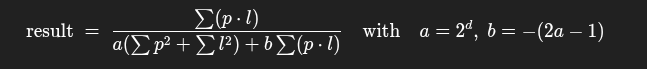

Here the depth dependent constant d is an integer hyperparameter as d increases, a increases this changes how strict the similarity becomes. This is not something that changes with the depth of the model.

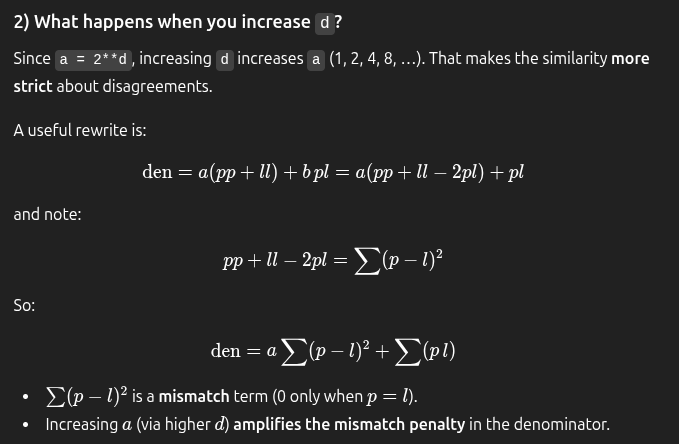

If p = l perfectly, mismatch is 0 similarity becomes 1 for any d.
If there is any mismatch, higher d usually makes the denominator larger -> similarity tends to decrease.
So the goal is not "similarity should be higher for deeper d."The goal is: as the model improves, similarity increases; d just changes how harshly mismatch are penalized.

denum = a*(pp+ll) + b*pl

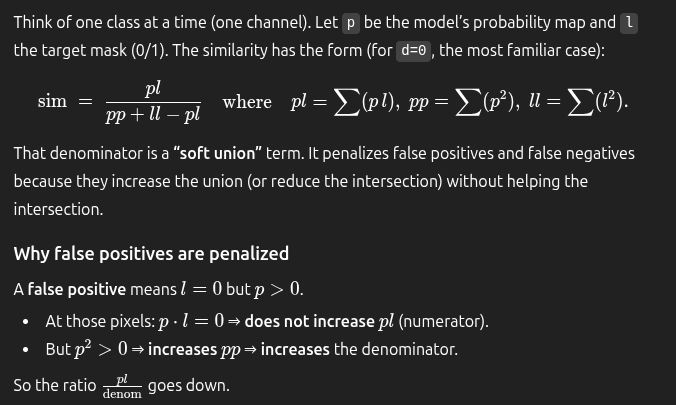
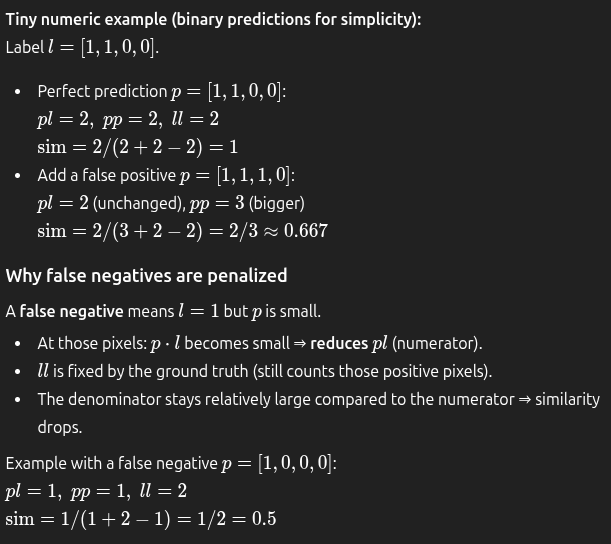

In [27]:
from typing import List

def inner_prod(prob, label,axis:List[int]):
    """
    Compute the overlap (inner product) between `prob` and `label` by multiplying them
    element-wise and summing over the dimensions in `axis` (e.g., spatial H,W). This is
    used as the soft “intersection” term Σ(prob·label) in Tanimoto/IoU-style similarity.
    `keepdim=True` preserves reduced dims for broadcasting in later computations.
    """
    return (prob * label).sum(dim=axis,keepdim=True)


# Custom definition that avoids resulting in exploding gradients when both inputs are zero.
class tnmt_2d(torch.autograd.Function):
    @staticmethod
    def forward(ctx,p:torch.Tensor,l:torch.Tensor,d:int,axis:List[int]=[2,3]): 
        pl = inner_prod(p,l,axis)
        pp = inner_prod(p,p,axis)
        ll = inner_prod(l,l,axis)
        a = 2**d
        b = -(2.*a-1.)
        # This is a normalization term that penalizes false positive and false negative.
        denum = a*(pp+ll) + b*pl #+ 1.e-5
        scale = torch.reciprocal(denum)
        scale = torch.nan_to_num(scale, nan=0.0,posinf=1.,neginf=-1)
        ctx.save_for_backward(p,l,pl,pp,ll,scale)
        ctx.a = a
        result = pl*scale
        return result
    
    @staticmethod 
    def backward(ctx,grad_output):
        p, l, pl, pp, ll, scale = ctx.saved_tensors
        a = ctx.a
        ascale2 = (a*scale)*scale
        ppmll  = pp+ll
        result_p = ascale2 *(-2.*p*pl + l *ppmll)
        result_l = ascale2 *(-2.*l*pl + p *ppmll)
        return result_p  * grad_output, result_l  * grad_output, None, None     


class FTanimoto(torch.nn.Module):
    """
    This is the average fractal Tanimoto set similarity with complement.
    """
    def __init__(self, depth=0, axis=[2,3],mode='exact'):
        super().__init__()
        if depth == 0:
            self.scale=1.
        else:
            self.scale = 1./(depth+1.)
        self.depth=depth
        self.axis=axis
        if mode=='exact' or depth==0:
            self.tnmt_base = self.tnmt_base_exact
        elif mode=='avg':
            self.tnmt_base = self.tnmt_base_avg
        else:
            raise  ValueError("variable mode must be one of 'avg' or 'exact', default == 'avg'")

    def set_depth(self,depth):
        assert depth >= 0, "Expecting depth >= 0, aborting ..."
        if depth == 0:
            scale=1.
        else:
            scale = 1./(depth+1.)
        self.scale = torch.tensor(scale)
        self.depth = depth 

    @torch.jit.export
    def tnmt_base_avg(self, preds, labels):
        if self.depth==0:
            return tnmt_2d.apply(preds,labels,self.depth,self.axis)
        else:
            result = 0.0
            for d in range(self.depth+1):
                result = result + tnmt_2d.apply(preds,labels,d,self.axis)
            return result * self.scale


    @torch.jit.export
    def tnmt_base_exact(self, preds, labels):
        return tnmt_2d.apply(preds,labels,self.depth,self.axis)

    def forward(self, preds, labels):
            l12 = self.tnmt_base(preds,labels)
            l12 = l12 + self.tnmt_base(1.-preds, 1.-labels)
            return 0.5*l12

In [28]:
class ftnmt_loss(torch.nn.Module):
    def __init__(self, depth=0, axis=[2,3], mode='exact'):
        super(ftnmt_loss,self).__init__()
        self.ftnmt = FTanimoto(depth=depth, axis=axis,mode=mode)

    def forward(self,preds,labels):
        sim = self.ftnmt(preds,labels)
        return (1. - sim).mean()

In [29]:
import albumentations as A
from albumentations.core.transforms_interface import  ImageOnlyTransform
class RSRandomBrightnessContrast(object):
    """Randomly change brightness and contrast of the input image.
    Args:
        brightness_limit ((float, float) or float): factor range for changing brightness.
            If limit is a single float, the range will be (-limit, limit). Default: (-0.2, 0.2).
        contrast_limit ((float, float) or float): factor range for changing contrast.
            If limit is a single float, the range will be (-limit, limit). Default: (-0.2, 0.2).
        brightness_by_max (Boolean): If True adjust contrast by image dtype maximum,
            else adjust contrast by image mean.
        p (float): probability of applying the transform. Default: 0.5.
    Targets:
        image
    Image types:
        uint8, float32
    """

    def __init__(
        self,
        norm,
        brightness_limit=0.2,
        contrast_limit=0.2,
        brightness_by_max=True,
        always_apply=False,
        p=0.5,
    ):

        self.trans = A.RandomBrightnessContrast(brightness_limit=brightness_limit,contrast_limit=contrast_limit, brightness_by_max=brightness_by_max, always_apply=always_apply, p=p)
        self.norm = norm
    

    def __call__(self,timg):
        timg_denormed = self.norm.restore(timg)
        tscale = np.iinfo(str(timg_denormed.dtype)).max
        timg_denormed = timg_denormed.astype(np.float32) / tscale
        
        transformed = self.trans(image=timg_denormed.transpose([1,2,0]))['image']
        transformed = transformed * tscale
        transformed = self.norm(transformed.transpose([2,0,1]))
        return transformed
        
        
       
class TrainingTransform(object):
    def __init__(self, NClasses, prob = 1., mode='train', compress=255., norm = None):
        self.NClasses = NClasses
        self.distance_scale=1. / compress
        self.geom_trans = A.Compose([
                    A.OneOf([
                        A.HorizontalFlip(p=1),
                        A.VerticalFlip(p=1),
                        A.ElasticTransform(p=1), 
                        A.GridDistortion(distort_limit=0.4,p=1.),
                        A.ShiftScaleRotate(shift_limit=0.25, scale_limit=(0.75,1.25), rotate_limit=180, p=1.0), 
                        ],p=1.)
                    ],
            p = prob)
        self.norm = norm
        if norm is not None:
            self.img_trans = RSRandomBrightnessContrast(norm = norm,brightness_limit=.1,contrast_limit=.1, brightness_by_max=False, p=1) 
        if mode=='train':
            self.mytransform = self.transform_train
        elif mode =='valid':
            self.mytransform = self.transform_valid
        else:
            raise ValueError('transform mode can only be train or valid')

    def transform_valid(self, timg, tmask):
        tmask = tmask.copy()
        tmask[2* self.NClasses:] = tmask[ 2* self.NClasses:] * self.distance_scale
        return timg, tmask

    def transform_train(self, timg, tmask):
        tmask = tmask.copy()
        tmask[2* self.NClasses:] = tmask[2* self.NClasses:] * self.distance_scale
        if isinstance(timg,list):
            nitems = len(timg)
            if self.norm is not None:
                timg = [self.img_trans(ttimg) for ttimg in timg] 
            timg = np.concatenate(timg,axis=0)

            if len(timg.shape) == 4:
                c,t,h,w = timg.shape
                timg = timg.reshape(c*t,h,w)
                result = self.geom_trans(image=timg.transpose([1,2,0]),mask=tmask.transpose([1,2,0]))
                timg_t, tmask_t = result.values()
                timg_t = timg_t.transpose([2,0,1])
                tmask_t = tmask_t.transpose([2,0,1])

                timg_t = timg_t.reshape(c,t,h,w)

            else:
                result = self.geom_trans(image=timg.transpose([1,2,0]),mask=tmask.transpose([1,2,0]))
                timg_t, tmask_t = result.values()
                timg_t = timg_t.transpose([2,0,1])
                tmask_t = tmask_t.transpose([2,0,1])
            
            timg_t = np.split(timg_t,nitems,axis=0)

        else:
            if self.norm is not None:
                timg = self.img_trans(timg) 
 
            if len(timg.shape) == 4:
                c,t,h,w = timg.shape
                timg = timg.reshape(c*t,h,w)
                result = self.geom_trans(image=timg.transpose([1,2,0]),mask=tmask.transpose([1,2,0]))
                timg_t, tmask_t = result.values()
                timg_t = timg_t.transpose([2,0,1])
                tmask_t = tmask_t.transpose([2,0,1])

                timg_t = timg_t.reshape(c,t,h,w)

            else:
                result = self.geom_trans(image=timg.transpose([1,2,0]),mask=tmask.transpose([1,2,0]))
                timg_t, tmask_t = result.values()
                timg_t = timg_t.transpose([2,0,1])
                tmask_t = tmask_t.transpose([2,0,1])

        return timg_t, tmask_t

    def __call__(self, timg, tmask):        
        return self.mytransform(timg,tmask) 

# Training without rockdb

In [30]:
import numpy as np
import rasterio, glob, xarray as xr
import os,sys

In [31]:
class AI4BNormal_S2(object):
    def __init__(self):

        self._mean_s2 = np.array([5.4418573e+02, 7.6761194e+02, 7.1712860e+02, 2.8561428e+03 ]).astype(np.float32) 
        self._std_s2  = np.array( [3.7141626e+02, 3.8981952e+02, 4.7989127e+02 ,9.5173022e+02]).astype(np.float32) 

    def __call__(self,img):

        temp = img.astype(np.float32)
        temp2 = temp.T
        temp2 -= self._mean_s2
        temp2 /= self._std_s2

        temp = temp2.T
        return temp


    
import albumentations as A
class TrainingTransformS2(object):
    # Built on Albumentations, this provides geometric transformation only  
    def __init__(self,  prob = 1., mode='train', norm = AI4BNormal_S2() ):
        self.geom_trans = A.Compose([
                    A.RandomCrop(width=128, height=128, p=1.0),  # Always apply random crop
                    A.OneOf([
                        A.HorizontalFlip(p=1),
                        A.VerticalFlip(p=1),
                        A.ElasticTransform(p=1), # VERY GOOD - gives perspective projection, really nice and useful - VERY SLOW   
                        A.GridDistortion(distort_limit=0.4,p=1.),
                        A.ShiftScaleRotate(shift_limit=0.25, scale_limit=(0.75,1.25), rotate_limit=180, p=1.0), # Most important Augmentation   
                        ],p=1.)
                    ],
            additional_targets={'imageS1': 'image','mask':'mask'},
            p = prob)
        if mode=='train':
            self.mytransform = self.transform_train
        elif mode =='valid':
            self.mytransform = self.transform_valid
        else:
            raise ValueError('transform mode can only be train or valid')
            
            
        self.norm = norm
        
    def transform_valid(self, data):
        timgS2, tmask = data
        if self.norm is not None:
            timgS2 = self.norm(timgS2)
        
        tmask= tmask 
        return timgS2,  tmask.astype(np.float32)

    def transform_train(self, data):
        timgS2, tmask = data
        
        if self.norm is not None:
            timgS2 = self.norm(timgS2)

        
        tmask= tmask 
        tmask = tmask.astype(np.float32)
        # Special treatment of time series
        c2,t,h,w = timgS2.shape
        #print (c2,t,h,w)              
        timgS2 = timgS2.reshape(c2*t,h,w)
        result = self.geom_trans(image=timgS2.transpose([1,2,0]),
                                 mask=tmask.transpose([1,2,0]))
        timgS2_t = result['image']
        tmask_t  = result['mask']
        timgS2_t = timgS2_t.transpose([2,0,1])
        tmask_t = tmask_t.transpose([2,0,1])
        
        c2t,h2,w2 = timgS2_t.shape

        
        timgS2_t = timgS2_t.reshape(c2,t,h2,w2)
        return timgS2_t,  tmask_t
    def __call__(self, *data):
        return self.mytransform(data)

In [32]:
class AI4BDataset(torch.utils.data.Dataset):
    def __init__(self, path_to_data=r'/path/to/AI4BOUNDARIES/sentinel2/',transform=TrainingTransformS2(), mode='train', ntrain=0.9):
        
        self.flnames_s2_img = sorted(glob.glob(os.path.join(path_to_data,r'images/*/*.nc')))
        self.flnames_s2_mask = sorted(glob.glob(os.path.join(path_to_data,r'masks/*/*.tif')))
        
        assert len(self.flnames_s2_img) == len(self.flnames_s2_mask), ValueError("Some problem, the masks and images are not in the same numbers, aborting")
        
        tlen = len(self.flnames_s2_img)
        
        if mode=='train':
            self.flnames_s2_img = self.flnames_s2_img[:int(ntrain*tlen)]
            self.flnames_s2_mask = self.flnames_s2_mask[:int(ntrain*tlen)]
        elif mode=='valid':
            self.flnames_s2_img = self.flnames_s2_img[int(ntrain*tlen):]
            self.flnames_s2_mask = self.flnames_s2_mask[int(ntrain*tlen):]
        else:
            raise ValueError("Cannot undertand mode::{}, should be either train or valid, aborting...".format(mode))
            
        self.transform=transform                                                              
    # Helper function to read nc to raster 
    def ds2rstr(self,tname):
        variables2use=['B2','B3','B4','B8'] # ,'NDVI']
        ds = xr.open_dataset(tname)
        ds_np = np.concatenate([ds[var].values[None] for var in variables2use],0)

        return ds_np

    def read_mask(self,tname):
        return rasterio.open(tname).read((1,2,3))

    
    def __getitem__(self,idx):
        tname_img = self.flnames_s2_img[idx]
        tname_mask = self.flnames_s2_mask[idx]
        
        timg = self.ds2rstr(tname_img)
        tmask = self.read_mask(tname_mask)
        
        if self.transform is not None:
            timg, tmask = self.transform(timg,tmask)
            
        return timg, tmask
    
    def __len__(self):
        return len(self.flnames_s2_img)

/opt/conda/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [33]:
mydataset = AI4BDataset("ai_boundaries")

In [34]:
timg, tmask = mydataset[10]

In [35]:
print(timg.shape, tmask.shape)

(4, 6, 128, 128) (3, 128, 128)


In [36]:
from earthpy.plot import plot_rgb

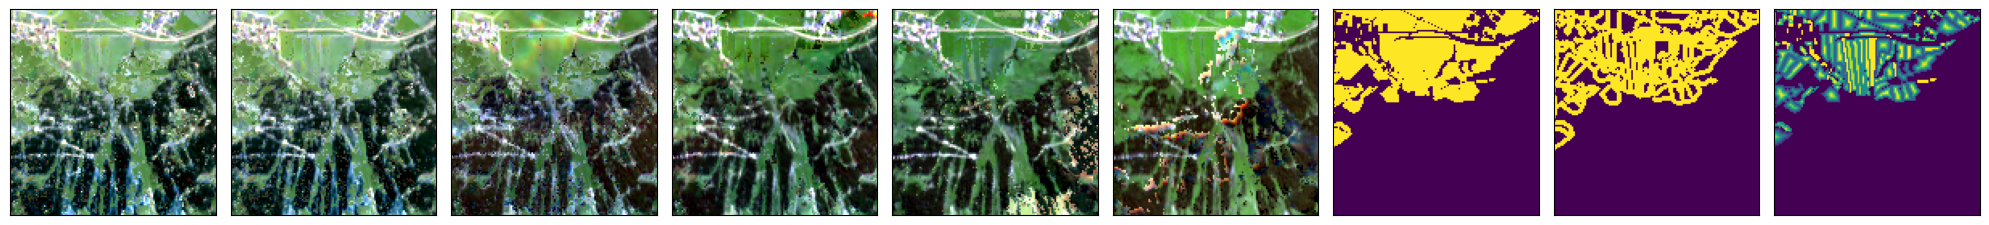

In [37]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 9, figsize=(20, 5))

for i in range(6):
    plot_rgb(timg[:,i],ax=axs[i],stretch=True)
for i in range(3):
    axs[6+i].imshow(tmask[i])
    axs[6+i].set_xticks([])
    axs[6+i].set_yticks([])
    
plt.tight_layout()

In [38]:
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

# Total Image: 6838 Training && testing: 760

def make_subset(ds, n, seed=0):
    n = min(n, len(ds))
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(ds), generator=g)[:n].tolist()
    return Subset(ds, idx)
    
def train(args):
    num_epochs = args.epochs
    batch_size = args.batch_size
    data_root = "ai_boundaries"
    torch.manual_seed(0)
    device = torch.device("cuda:0")
    """
    This is the number of classes the model predicts per pixels for a given output map. NClasses = 2
    means the model is configured to do 2 class semantic segmentation. In PTAVIT3D the segmentation head is 
    multitask, it predict extent, boundary, and distance for each class. 
    so the total number of output channel becomes: 3 x Nclasses = 3x2 = 6
    2 channel for extent, 2 channel for boundary and 2 channel for distance transform. 
    Here it make sense to have 2 channel for boundary as a binary classification per pixel (boundary / not boundary)
    2 channel for extent (background, field) and 2 channel for distance  is dis
    """
    NClasses = 1
    nf = 16 # Base number of feature channels inside the network.
    verbose = True
    model_config = {'in_channels': 4,
                    'spatial_size_init': (128, 128),
                    'depths': [1, 1, 2, 1],
                    'nfilters_init': nf,
                    'nheads_start': max(1, nf // 4),
                    'NClasses': NClasses,
                    'verbose': verbose,
                    'segm_act': 'sigmoid'}

    model = ptavit3d_dn(**model_config).to(device)
    criterion = ftnmt_loss()
    criterion_features = ftnmt_loss(axis=[-3, -2, -1])
    optimizer = torch.optim.RAdam(model.parameters(), lr=1e-3, eps=1.e-6)
    scaler = GradScaler()

    train_full = AI4BDataset(path_to_data=data_root, mode="train")
    valid_full = AI4BDataset(path_to_data=data_root, mode="valid")
    # train_dataset = make_subset(train_full, 100, seed=0)
    # valid_dataset = make_subset(valid_full, 30, seed=1)

    # assert len(train_dataset) > 0, f"No training samples found under {data_root}"
    # assert len(valid_dataset) > 0, f"No validation samples found under {data_root}"
    
    train_loader = DataLoader(dataset=train_full, batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)
    
    valid_loader = DataLoader(dataset=valid_full, batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)

    start = datetime.now()
    epoch_pbar = tqdm(range(num_epochs), desc="Epochs", position=0)
    for epoch in epoch_pbar:
        tot_loss = 0
        n_batches = 0
        model.train()
        train_pbar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc=f"Training Epoch {epoch}",
            position=1,
            leave=False,
            dynamic_ncols=True,
        )
        for i, (images, labels) in train_pbar:
            if DEBUG and i > 5:
                break
                
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type=device.type, dtype=torch.bfloat16):
                preds_target = model(images)
                loss = mtsk_loss(preds_target, labels, criterion, NClasses)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            loss_val = float(loss.item())
            tot_loss += loss_val
            n_batches += 1
            avg_loss = tot_loss / n_batches
            train_pbar.set_postfix(loss=f"{loss_val:.4f}", avg=f"{avg_loss:.4f}")

        avg_train_loss = tot_loss / max(1, n_batches)
        epoch_pbar.set_postfix(avg_train_loss=f"{avg_train_loss:.4f}")

        kwargs = monitor_epoch(model, epoch, valid_loader, NClasses, device)
        kwargs['tot_train_loss'] = tot_loss
        kwargs['avg_train_loss'] = avg_train_loss
        if verbose:
            msg_parts = [
                f"epoch={epoch}",
                f"avg_train_loss={avg_train_loss:.4f}",
            ]
            for k in ("acc_target_vV", "precision_target_vV", "recall_target_vV", "mcc_target_vV", "kappa_target_vV"):
                if k in kwargs:
                    msg_parts.append(f"{k}={kwargs[k]}")
            epoch_pbar.write(", ".join(msg_parts))

    if verbose:
        print("Training completed in: " + str(datetime.now() - start))

In [39]:
def main():
    class Args:
        def __init__(self):
            self.epochs = 40
            self.batch_size = 1

    args = Args()
        
    train(args)

In [ ]:
model = main()

@@@@@@@@@@@@@@@@@   Encoder Block Going Down   @@@@@@@@@@@@@@@@@@@@@
depth:= 0, layer_dim_in: 16, layer_dim: 16, stage_depth::1, spatial_size::(32, 32), scales::[2, 8, 8]
depth:= 1, layer_dim_in: 16, layer_dim: 32, stage_depth::1, spatial_size::(16, 16), scales::[4, 4, 4]
depth:= 2, layer_dim_in: 32, layer_dim: 64, stage_depth::2, spatial_size::(8, 8), scales::[8, 2, 2]
depth:= 3, layer_dim_in: 64, layer_dim: 128, stage_depth::1, spatial_size::(4, 4), scales::[16, 1, 1]
@@@@@@@@@@@@@@@@@   Decoder Block coming up   @@@@@@@@@@@@@@@@@@@@@
depth:= 4, layer_dim_in: 64, layer_dim: 64, stage_depth::2, spatial_size::(32, 32), scales::[8, 2, 2]
depth:= 5, layer_dim_in: 32, layer_dim: 32, stage_depth::1, spatial_size::(64, 64), scales::[4, 4, 4]
depth:= 6, layer_dim_in: 16, layer_dim: 16, stage_depth::1, spatial_size::(128, 128), scales::[2, 8, 8]


Training Epoch 0:   0%|       | 14/6838 [00:36<4:58:56,  2.63s/it, avg=0.5079, loss=0.5901]

In [ ]:
# I changed the Classification function mostly

import torch

print("is_available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())

try:
    torch.cuda.init()
    print("init: OK")
    print("device_name_0:", torch.cuda.get_device_name(0))
except Exception as e:
    print("init error:", repr(e))


In [ ]:
# def train(args):
#     num_epochs = args.epochs
#     batch_size = args.batch_size
#     # dist.init_process_group(backend ="nccl")
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     torch.manual_seed(0)
#     if device.type == "cuda":
#         torch.cuda.manual_seed_all(0)
#     NClasses = 6
#     nf = 96
#     verbose = True
#     model_config = {
#         'in_channels':4,
#         'spatial_size_init':(128,128),
#         'depths':[2,2,5,2],
#         'nfilters_init':nf,
#         'nheads_start':nf//4,
#         'NClasses':NClasses,
#         'verbose':verbose,
#         'segm_act':'sigmoid'
#     }
#     model = ptavit3d_dn(**model_config).to(device)
#     criterion = ftnmt_loss()
#     criterion_features = ftnmt_loss(axis=[-3,-2,-1]) # this is used to measure similarity per batch per feature channel aggregating over the full spatio-temporal volume.
#     optimizer = torch.optim.RAdam(model.parameters(), lr=1e-3, eps=1.e-6)
#     transform_train = TrainingTransform(NClasses=NClasses, mode='train')
#     transform_valid = TrainingTransform(NClasses=NClasses, mode='valid')
#     train_dataset = RocksDBDataset(
#                  flname_db= '../../data/train.db',
#                  transform=transform_train,
#                  num_workers=4)
#     valid_dataset = RocksDBDataset(
#                  flname_db= '../../data/valid.db',
#                  transform=transform_valid,
#                  num_workers=4)
#     pin = (device.type == "cuda")
#     train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size,
#                               shuffle=False, num_workers=0, pin_memory=True,
#                               sampler=train_sampler)

#     valid_loader = DataLoader(dataset=valid_dataset, batch_size=batch_size,
#                               shuffle=False, num_workers=0, pin_memory=True,
#                               sampler=valid_sampler)
#     start = datetime.now()
#     for epoch in range(num_epochs):
#         model.train()
#         tot_loss = 0
#         for i, data in enumerate(train_loader):
#             if DEBUG and i>5:
#                 break
#             images, labels = data
#             images = images.to(device, non_blocking=True)
#             labels = labels.to(device, non_blocking=True)
#             optimizer.zero_grad(set_to_none=True)
#             preds_target = model(images)
#             loss = mtsk_loss(preds_target, labels,criterion,NClasses)
#             loss.backward()
#             optimizer.step()
#             tot_loss += float(loss.item())
#         kwargs = monitor_epoch(model, epoch, valid_loader, NClasses)
#         kwargs['tot_train_loss'] = tot_loss
#         if verbose:
#             output_str = ', '.join(f'{k}:: {v}, |===|, ' for k, v in kwargs.items())
#             print(output_str)

#     if verbose:
#         print("Training completed in: " + str(datetime.now() - start))